In [1]:
from pathlib import Path
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

os.environ.setdefault('PROJ_LIB', str(Path('external/proj')))
import track

OFES_DATA_START = '2003-01-01'
OFES_DATA_END = '2003-12-31'
OFES_OUTPUT_ROOT = Path('plot_outputs/do/ofes_np30_ke')
GLOBAL_OUTPUT_ROOT = Path('plot_outputs/do/global_ocean')
FIGURE_ROOT = Path('ofes_figures_preview/11_manuscript_figures')
SURFACE_ROOT = OFES_OUTPUT_ROOT / 'surface_eddy'
VENTILATION_DAILY_TABLE = OFES_OUTPUT_ROOT / 'primary_trajectory_ventilation' / 'daily_ventilation_diagnostics.parquet'
REPRESENTATIVE_EVENT_IDS = [
    'OFES_DO50_E000002',
    'OFES_DO50_E000239',
    'OFES_DO50_E000176',
]


def _read_table(path, columns=None):
    path = Path(path)
    if not path.is_file():
        return pd.DataFrame(columns=columns or [])
    frame = pd.read_parquet(path)
    if columns is None:
        return frame
    return frame.loc[:, [column for column in columns if column in frame.columns]]


def _try(callable_, *args, **kwargs):
    try:
        return callable_(*args, **kwargs)
    except (FileNotFoundError, RuntimeError, ValueError, KeyError, OSError, TypeError) as exc:
        print(f'{callable_.__name__}: formal output unavailable ({type(exc).__name__})')
        return None


def _preview(frame, columns, rows=8):
    if isinstance(frame, pd.DataFrame):
        selected = [column for column in columns if column in frame.columns]
        display(frame.loc[:, selected].head(rows) if selected else frame.head(rows))


## 1. Setup and formal output paths

The paths below are the project-level semantic locations. Producers write there, while readers consume the same named outputs on later runs.

In [2]:
path_summary = pd.DataFrame({
    'item': ['OFES window', 'OFES products', 'supporting tables', 'manuscript figures'],
    'value': [
        f'{OFES_DATA_START} to {OFES_DATA_END}',
        str(OFES_OUTPUT_ROOT),
        str(OFES_OUTPUT_ROOT),
        str(FIGURE_ROOT),
    ],
})
display(path_summary)


,item,value
0,OFES window,2003-01-01 to 2003-12-31
1,OFES products,plot_outputs/do/ofes_np30_ke
2,supporting tables,plot_outputs/do/ofes_np30_ke
3,manuscript figures,ofes_figures_preview/11_manuscript_figures


The notebook does not select an implicit run. A producer is called again only when its formal output is absent or has been deliberately removed; otherwise the reader is enough for inspection and figure updates.

## 2. OFES data semantics and B-grid validation

Before event analysis, this section records the delivered OFES conventions: the MOM3 Arakawa-B horizontal grid, z-level depths interpreted in metres, and the public variable units. The analytic grid check is available as a lightweight formal producer.

In [ ]:
# Optional lightweight validation; it does not read the annual OFES fields.
grid_validation = track.validate_ofes_grid_scv_v2_analytic()


In [3]:
ofes_semantics = track._OFES_CFG
data_semantics = pd.DataFrame([
    ('horizontal_grid', ofes_semantics.get('horizontal_grid')),
    ('depth_units', ofes_semantics.get('depth_units')),
    ('source_vertical_units_attribute', ofes_semantics.get('source_vertical_units_attribute')),
    ('tracer_variables', ', '.join(ofes_semantics.get('tracer_vars', []))),
    ('velocity_variables', ', '.join(ofes_semantics.get('velocity_vars', []))),
], columns=['item', 'value'])
display(data_semantics)


,item,value
0,horizontal_grid,arakawa_b
1,depth_units,m
2,source_vertical_units_attribute,millibar
3,tracer_variables,"do2, temp, salinity"
4,velocity_variables,"u, v, w"


These conventions are metadata consumed by the formal readers and integrators. No event classification is performed in the notebook.

## 3. Annual ΔDO event catalog

Question: which persistent ΔDO objects are present in the annual 300–1000 m OFES window? The producer scans the daily fields and writes the event index; the reader exposes the event and scan tables for inspection.

In [ ]:
catalog_run = track.build_ofes_delta_do_event_catalog(
    start_date=OFES_DATA_START,
    end_date=OFES_DATA_END,
    output_dir=OFES_OUTPUT_ROOT / 'event_catalog',
)


In [4]:
catalog_result = _try(
    track.load_ofes_event_catalog,
    output_dir=OFES_OUTPUT_ROOT / 'event_catalog',
)
if catalog_result is not None:
    _preview(catalog_result.get('event_catalog'), ['event_id', 'threshold', 'peak_date', 'peak_lon', 'peak_lat', 'peak_depth_m'])
    _preview(catalog_result.get('scan_summary'), ['date', 'object_count', 'event_count'])


,event_id,threshold,peak_date,peak_lon,peak_lat,peak_depth_m
0,OFES_DO20_E001645,20.0,2003-05-15,155.082782,31.382819,418.340454
1,OFES_DO20_E000457,20.0,2003-03-08,142.916237,35.782775,309.440887
2,OFES_DO20_E001441,20.0,2003-05-17,144.482888,31.749482,702.889526
3,OFES_DO20_E002217,20.0,2003-06-08,142.682906,35.549444,309.440887
4,OFES_DO20_E002163,20.0,2003-06-06,146.782865,36.582767,539.385803
5,OFES_DO20_E001248,20.0,2003-04-15,143.749562,35.582777,403.885406
6,OFES_DO20_E000539,20.0,2003-03-13,142.282910,35.616110,348.239563
7,OFES_DO20_E002771,20.0,2003-07-27,144.816218,34.249457,702.889526


,date
0,2003-01-01
1,2003-01-01
2,2003-01-01
3,2003-01-02
4,2003-01-02
5,2003-01-02
6,2003-01-03
7,2003-01-03


The catalog is an event-level index. Later diagnostics use its event IDs and dates rather than reimplementing detection logic in this notebook.

## 4. Primary event population and deep-process subset

The primary OFES population is the DO50 set with anomaly peaks at depths ≥300 m in the 300–1000 m candidate window. The current formal census contains 161 quality-eligible events. The nested 500–1000 m deep-process scope contains 59 quality events, with 56 complete background-annulus/population events in the existing deep analysis. Primary lifecycle, trajectory, tracer, ventilation, daily water-mass, w-along, winter-MLD, and transition products below use the primary scope; onset/patch and representative case audits remain deep-only auxiliaries.

In [ ]:
event_diagnostic_run = track.diagnose_ofes_quality_eligible_events(
    catalog_dir=OFES_OUTPUT_ROOT / 'event_catalog',
    output_dir=OFES_OUTPUT_ROOT / 'quality_event_diagnostics',
)
population_run = track.run_ofes_event_population(
    population_scope='primary_300_1000',
    diagnostic_dir=OFES_OUTPUT_ROOT / 'quality_event_diagnostics',
    output_dir=OFES_OUTPUT_ROOT / 'primary_event_population',
)
deep_population_run = track.generalize_ofes_deep_events(
    diagnostic_dir=OFES_OUTPUT_ROOT / 'quality_event_diagnostics',
    output_dir=OFES_OUTPUT_ROOT / 'deep_event_population',
)
lifecycle_run = track.diagnose_ofes_event_lifecycle(
    population_scope='primary_300_1000',
    population_dir=OFES_OUTPUT_ROOT / 'primary_event_population',
    output_dir=OFES_OUTPUT_ROOT / 'primary_event_lifecycle',
)
deep_lifecycle_run = track.diagnose_ofes_event_lifecycle(
    population_scope='deep_500_1000',
    population_dir=OFES_OUTPUT_ROOT / 'deep_event_population',
    output_dir=OFES_OUTPUT_ROOT / 'deep_event_lifecycle',
)
onset_run = track.diagnose_ofes_event_onset_regimes(
    population_dir=OFES_OUTPUT_ROOT / 'deep_event_population',
    output_dir=OFES_OUTPUT_ROOT / 'deep_event_onset',
)
patch_run = track.diagnose_ofes_water_mass_patch_continuity(
    onset_dir=OFES_OUTPUT_ROOT / 'deep_event_onset',
    output_dir=OFES_OUTPUT_ROOT / 'deep_event_patch',
)


In [5]:
event_diagnostics_result = _try(
    track.load_ofes_quality_event_diagnostics,
    output_dir=OFES_OUTPUT_ROOT / 'quality_event_diagnostics',
)
event_population_result = _try(
    track.load_ofes_event_population,
    population_scope='primary_300_1000',
    output_dir=OFES_OUTPUT_ROOT / 'primary_event_population',
)
deep_population_result = _try(
    track.load_ofes_event_population,
    population_scope='deep_500_1000',
    output_dir=OFES_OUTPUT_ROOT / 'deep_event_population',
)
onset_result = _try(track.load_ofes_event_onset, output_dir=OFES_OUTPUT_ROOT / 'deep_event_onset')
patch_result = _try(track.load_ofes_event_patch_continuity, output_dir=OFES_OUTPUT_ROOT / 'deep_event_patch')
lifecycle_result = _try(track.load_ofes_event_lifecycle, output_dir=OFES_OUTPUT_ROOT / 'primary_event_lifecycle')
evolution_result = _try(track.load_ofes_event_evolution, output_dir=OFES_OUTPUT_ROOT / 'event_evolution')
if event_diagnostics_result is not None:
    _preview(event_diagnostics_result.get('selected_events'), ['event_id', 'threshold', 'peak_date', 'rank_within_threshold'])
if event_population_result is not None:
    _preview(event_population_result.get('population_peak_diagnostics'), ['event_id', 'threshold', 'peak_date', 'delta_do_max', 'water_mass_do_contrast', 'heave_do_contribution', 'rotation_dominated'])
if deep_population_result is not None:
    _preview(deep_population_result.get('population_peak_diagnostics'), ['event_id', 'population_scope', 'peak_depth_m', 'population_diagnostic_passed'])
if onset_result is not None:
    _preview(onset_result.get('event_onset_summary'), ['event_id', 'start_date', 'peak_date', 'onset_regime'])
if patch_result is not None:
    _preview(patch_result.get('patch_summary'), ['event_id', 'continuity_passed', 'trajectory_interpretation'])
if lifecycle_result is not None:
    _preview(lifecycle_result.get('event_summary'), ['event_id', 'persistent_anticyclonic_rotational_carrier', 'scv_compatible'])


load_ofes_event_evolution: formal output unavailable (FileNotFoundError)


,event_id,threshold,peak_date,rank_within_threshold
0,OFES_DO50_E000002,50.0,2003-01-26,1
1,OFES_DO50_E000222,50.0,2003-06-03,2
2,OFES_DO50_E000276,50.0,2003-07-14,3
3,OFES_DO50_E000034,50.0,2003-01-31,4
4,OFES_DO50_E000122,50.0,2003-03-13,5
5,OFES_DO50_E000073,50.0,2003-02-20,6
6,OFES_DO50_E000267,50.0,2003-06-29,7
7,OFES_DO50_E000260,50.0,2003-06-22,8


,event_id,threshold,peak_date,delta_do_max,water_mass_do_contrast,heave_do_contribution,rotation_dominated
0,OFES_DO50_E000002,50.0,2003-01-26,139.898438,136.054829,7.319983,True
1,OFES_DO50_E000222,50.0,2003-06-03,131.630005,131.749717,-10.951653,True
2,OFES_DO50_E000276,50.0,2003-07-14,105.853798,117.147807,54.563085,True
3,OFES_DO50_E000034,50.0,2003-01-31,129.753601,142.809081,-12.162299,False
4,OFES_DO50_E000122,50.0,2003-03-13,126.084236,105.080781,20.145576,False
5,OFES_DO50_E000073,50.0,2003-02-20,76.484543,66.051825,18.430406,True
6,OFES_DO50_E000267,50.0,2003-06-29,77.557129,78.796106,1.995661,True
7,OFES_DO50_E000260,50.0,2003-06-22,137.945389,106.090133,46.760735,True


,event_id,population_scope,peak_depth_m,population_diagnostic_passed
0,OFES_DO50_E000002,deep_500_1000,539.385803,True
1,OFES_DO50_E000222,deep_500_1000,603.090820,True
2,OFES_DO50_E000276,deep_500_1000,664.494080,True
3,OFES_DO50_E000073,deep_500_1000,603.090820,True
4,OFES_DO50_E000267,deep_500_1000,603.090820,True
5,OFES_DO50_E000233,deep_500_1000,539.385803,True
6,OFES_DO50_E000054,deep_500_1000,603.090820,True
7,OFES_DO50_E000014,deep_500_1000,578.766052,True


,event_id,start_date,peak_date
0,OFES_DO50_E000002,2003-01-04,2003-01-26
1,OFES_DO50_E000239,2003-06-03,2003-06-06
2,OFES_DO50_E000176,2003-04-14,2003-04-16


,event_id
0,OFES_DO50_E000002
1,OFES_DO50_E000239
2,OFES_DO50_E000176


,event_id,persistent_anticyclonic_rotational_carrier,scv_compatible
0,OFES_DO50_E000002,True,False
1,OFES_DO50_E000222,False,False
2,OFES_DO50_E000276,True,True
3,OFES_DO50_E000034,False,False
4,OFES_DO50_E000073,True,True
5,OFES_DO50_E000267,True,True
6,OFES_DO50_E000260,False,False
7,OFES_DO50_E000233,False,False


The returned rows retain event-level denominators and the water-mass/heave decomposition. The notebook only selects columns for display.

## 5. Quality-eligible event census

This census separates the 161-event primary population from events that are merely present in the detector catalog. The formal loader/reducer below reports the peak-day water-mass/heave denominator and the primary-population dynamical counts used by the manuscript comparison.

In [ ]:
quality_run = track.diagnose_ofes_quality_eligible_events(
    catalog_dir=OFES_OUTPUT_ROOT / 'event_catalog',
    output_dir=OFES_OUTPUT_ROOT / 'quality_event_diagnostics',
)


In [6]:
quality_result = _try(
    track.load_ofes_quality_event_diagnostics,
    output_dir=OFES_OUTPUT_ROOT / 'quality_event_diagnostics',
)
if quality_result is not None:
    _preview(quality_result.get('event_diagnostic_summary'), ['event_id', 'diagnosed_days', 'passed_days', 'all_sampled_days_passed'])
population_census = track.summarize_ofes_analysis_populations(
    catalog_dir=OFES_OUTPUT_ROOT / 'event_catalog',
    diagnostic_dir=OFES_OUTPUT_ROOT / 'quality_event_diagnostics',
    population_scope='primary_300_1000',
    population_dir=OFES_OUTPUT_ROOT / 'primary_event_population',
)
primary_census = population_census.get('primary_quality_census')
if primary_census is not None:
    primary_count = primary_census['quality_event_count']
    decomposition_denominator = primary_census['water_mass_fraction_eligible_count']
    kinematic_denominator = primary_census['kinematic_eligible_count']
    display(pd.DataFrame([{
        'primary_events': primary_count,
        'water_mass_dominated': f"{primary_census['water_mass_dominated_count']}/{decomposition_denominator}",
        'median_water_mass_fraction': f"{100 * primary_census['median_water_mass_absolute_fraction']:.1f}%",
        'anticyclonic': f"{primary_census['anticyclonic_count']}/{kinematic_denominator}",
        'rotation_dominated': f"{primary_census['rotation_dominated_count']}/{kinematic_denominator}",
        'anticyclonic_rotation': f"{primary_census['anticyclonic_rotation_count']}/{kinematic_denominator}",
        'decomposition_evaluable': f"{decomposition_denominator}/{primary_count}",
        'kinematic_evaluable': f"{kinematic_denominator}/{primary_count}",
        'full_diagnostic_complete': f"{primary_census['all_sampled_days_complete_count']}/{primary_count}",
        'water_mass_fraction_eligible': primary_census['water_mass_fraction_eligible_count'],
        'kinematic_eligible_count': primary_census['kinematic_eligible_count'],
    }]))


,event_id,diagnosed_days,passed_days,all_sampled_days_passed
0,OFES_DO50_E000002,31,31,True
1,OFES_DO50_E000222,31,31,True
2,OFES_DO50_E000276,31,31,True
3,OFES_DO50_E000034,16,16,True
4,OFES_DO50_E000122,24,24,True
5,OFES_DO50_E000073,28,28,True
6,OFES_DO50_E000267,31,31,True
7,OFES_DO50_E000260,14,14,True


,primary_events,water_mass_dominated,median_water_mass_fraction,anticyclonic,rotation_dominated,anticyclonic_rotation,decomposition_evaluable,kinematic_evaluable,full_diagnostic_complete,water_mass_fraction_eligible,kinematic_eligible_count
0,161,138/156,78.2%,115/154,68/154,56/154,156/161,154/161,153/161,156,154


Quality eligibility is reported independently from the nested deep-process subset. The counts above come from the formal loader/reducer; missing event-level diagnostics remain explicit, while the downstream mechanism chapters use the primary scope and retain their own analysis-specific eligibility denominators.

## 6. Depth-gate sensitivity

Argo and the primary OFES definition both exclude direct upper-ocean influence with a 300 m minimum anomaly depth. The 100 m gate only tests whether the heave contribution changes when that depth is relaxed; it is a shallow upper-ocean sensitivity analysis, not a new formal event population. The decomposition denominator includes only peak events with finite water-mass/heave/closure diagnostics; the kinematic denominator independently includes only finite Ro/strain peaks, while full diagnostic completion is retained as a separate QC field. The 100 m gate is more heave-sensitive, whereas the 300 m primary estimate is the formal reference; the boundary-excluded summary is shown alongside the main estimate.

In [ ]:
depth_sensitivity_run = track.run_ofes_depth_gate_sensitivity(
    start_date=OFES_DATA_START,
    end_date=OFES_DATA_END,
    depth_gates_m=(100, 300),
    output_dir=OFES_OUTPUT_ROOT / 'depth_gate_sensitivity',
)


In [7]:
depth_sensitivity = _try(
    track.load_ofes_depth_gate_sensitivity,
    output_dir=OFES_OUTPUT_ROOT / 'depth_gate_sensitivity',
)
if depth_sensitivity is not None:
    depth_sensitivity_summary = depth_sensitivity['gate_summaries']
    display(depth_sensitivity_summary[[
        'gate_tag', 'minimum_depth_m', 'actual_lower_search_level_m',
        'actual_upper_search_level_m',
        'effective_detector_minimum_m',
        'catalog_event_count', 'catalog_rank_eligible_count',
        'quality_event_count',
        'catalog_event_counts_by_threshold',
        'peak_decomposition_eligible_count', 'peak_decomposition_missing_count',
        'peak_kinematic_eligible_count', 'peak_kinematic_missing_count',
        'peak_full_diagnostic_passed_count', 'peak_full_diagnostic_failed_count',
        'peak_fraction_eligible_count', 'median_peak_depth_m',
        'all_sampled_days_complete_count',
        'lower_search_boundary_peak_count', 'upper_search_boundary_peak_count',
        'median_water_mass_absolute_fraction',
        'median_heave_absolute_fraction',
        'median_abs_water_mass_do_contrast',
        'median_abs_heave_do_contribution',
        'median_water_mass_absolute_fraction_bootstrap95',
        'median_heave_absolute_fraction_bootstrap95',
        'water_mass_dominated_count', 'water_mass_dominated_denominator',
        'water_mass_dominated_fraction', 'water_mass_dominated_wilson95',
        'anticyclonic_denominator', 'rotation_dominated_denominator',
        'anticyclonic_count', 'rotation_dominated_count',
        'anticyclonic_rotation_count',
    ]])
    depth_sensitivity_secondary_summary = pd.DataFrame(
        depth_sensitivity['secondary_gate_summaries']
    )
    display(depth_sensitivity_secondary_summary[[
        'gate_tag', 'minimum_depth_m', 'quality_event_count',
        'peak_decomposition_eligible_count', 'peak_decomposition_missing_count',
        'peak_kinematic_eligible_count', 'peak_kinematic_missing_count',
        'peak_full_diagnostic_passed_count', 'peak_full_diagnostic_failed_count',
        'peak_fraction_eligible_count',
        'median_water_mass_absolute_fraction',
        'median_heave_absolute_fraction',
        'median_abs_water_mass_do_contrast',
        'median_abs_heave_do_contribution',
        'water_mass_dominated_count', 'water_mass_dominated_denominator',
        'water_mass_dominated_fraction', 'water_mass_dominated_wilson95',
        'anticyclonic_denominator', 'rotation_dominated_denominator',
        'anticyclonic_count', 'rotation_dominated_count',
        'anticyclonic_rotation_count',
    ]])


,gate_tag,minimum_depth_m,actual_lower_search_level_m,actual_upper_search_level_m,effective_detector_minimum_m,catalog_event_count,catalog_rank_eligible_count,quality_event_count,catalog_event_counts_by_threshold,peak_decomposition_eligible_count,...,median_heave_absolute_fraction_bootstrap95,water_mass_dominated_count,water_mass_dominated_denominator,water_mass_dominated_fraction,water_mass_dominated_wilson95,anticyclonic_denominator,rotation_dominated_denominator,anticyclonic_count,rotation_dominated_count,anticyclonic_rotation_count
0,depth100m,100.0,102.500000,995.052063,102.500000,1189,610,591,"{'do20': 14363, 'do35': 4866, 'do50': 1189}",482,...,"[0.2541061267373099, 0.304374778662816]",406,482,0.842324,"[0.8070982580899966, 0.8721356648465608]",529,529,312,261,163
1,depth300m,300.0,309.440887,995.052063,309.440887,309,162,161,"{'do20': 3458, 'do35': 1199, 'do50': 309}",156,...,"[0.1735312545849514, 0.23688930451169282]",138,156,0.884615,"[0.8249883550868361, 0.9257555438074602]",154,154,115,68,56


,gate_tag,minimum_depth_m,quality_event_count,peak_decomposition_eligible_count,peak_decomposition_missing_count,peak_kinematic_eligible_count,peak_kinematic_missing_count,peak_full_diagnostic_passed_count,peak_full_diagnostic_failed_count,peak_fraction_eligible_count,...,median_abs_heave_do_contribution,water_mass_dominated_count,water_mass_dominated_denominator,water_mass_dominated_fraction,water_mass_dominated_wilson95,anticyclonic_denominator,rotation_dominated_denominator,anticyclonic_count,rotation_dominated_count,anticyclonic_rotation_count
0,depth100m,100.0,473,403,70,411,62,361,112,403,...,28.513081,341,403,0.846154,"[0.80767406791909, 0.8780967500519533]",411,411,272,202,146
1,depth300m,300.0,136,132,4,129,7,129,7,132,...,18.247857,117,132,0.886364,"[0.8209608321588799, 0.9299144962240136]",129,129,109,57,52


In [8]:
depth_sensitivity_plot = _try(
    track.plot_ofes_depth_gate_sensitivity,
    depth_sensitivity,
    show_fig=True,
    save_fig=False,
    dpi=600,
)


## 7. Fixed-site and moving-core daily water-mass diagnostics

The daily producer evaluates the same water-mass/heave decomposition in fixed-site and moving-core geometries for the 300–1000 m primary scope. The reader returns both formal tables, and the plot consumes those tables without opening OFES fields; each geometry reports its own evaluable event-day denominator.

In [ ]:
daily_water_run = track.run_ofes_daily_water_mass_diagnostics(
    population_scope='primary_300_1000',
    population_dir=OFES_OUTPUT_ROOT / 'primary_event_population',
    lifecycle_dir=OFES_OUTPUT_ROOT / 'primary_event_lifecycle',
    output_dir=OFES_OUTPUT_ROOT / 'primary_daily_water_mass',
)


In [9]:
daily_water_result = _try(
    track.load_ofes_daily_water_mass_diagnostics,
    population_scope='primary_300_1000',
    output_dir=OFES_OUTPUT_ROOT / 'primary_daily_water_mass',
    geometry_mode='both',
)
if daily_water_result is not None:
    for geometry_name, geometry_result in daily_water_result.get('geometries', {}).items():
        print(geometry_name)
        _preview(geometry_result.get('event_summary'), ['event_id', 'water_mass_start', 'water_mass_peak', 'water_mass_last', 'observed_days'])


fixed_site


,event_id,water_mass_start,water_mass_peak,water_mass_last
0,OFES_DO50_E000001,-10.785591,150.201597,-52.322816
1,OFES_DO50_E000002,1.887655,136.054829,-16.025984
2,OFES_DO50_E000003,146.134949,146.134949,-59.038223
3,OFES_DO50_E000005,96.656597,96.656597,-6.042318
4,OFES_DO50_E000008,-1.714668,92.875899,92.875899
5,OFES_DO50_E000009,-0.588145,105.749390,105.749390
6,OFES_DO50_E000010,-27.620510,125.432502,-18.809869
7,OFES_DO50_E000011,-21.087323,47.223087,-64.747226


moving_core


,event_id,water_mass_start,water_mass_peak,water_mass_last
0,OFES_DO50_E000001,8.701954,76.050358,50.454057
1,OFES_DO50_E000002,-55.554506,98.928677,57.442972
2,OFES_DO50_E000003,146.134949,146.134949,27.932546
3,OFES_DO50_E000005,96.656597,96.656597,-33.537330
4,OFES_DO50_E000008,-14.351712,-17.285172,-17.285172
5,OFES_DO50_E000009,6.993280,-33.021293,-33.021293
6,OFES_DO50_E000010,156.490284,116.587139,-33.368016
7,OFES_DO50_E000011,15.986600,56.156805,69.393315


In [10]:
if daily_water_result is not None:
    daily_water_plot = _try(
        track.plot_ofes_daily_water_mass_diagnostics,
        daily_water_result,
        show_fig=True,
        save_fig=False,
    )


The two geometries are complementary views of the same events. Any difference is a geometric sensitivity result, not a new detector.

## 8. Vertical-velocity validation

The continuity and sign check is completed before trajectory integration. This reader and plot show the stored daily metrics; no raw velocity field is accessed by either cell. The downstream population trajectory products use the 300–1000 m primary scope; deep-only onset/patch audits remain separate.

In [ ]:
w_validation_run = track.validate_ofes_vertical_velocity(
    output_dir=OFES_OUTPUT_ROOT / 'vertical_velocity_validation',
)


In [11]:
w_validation_result = _try(
    track.load_ofes_vertical_velocity_validation,
    output_dir=OFES_OUTPUT_ROOT / 'vertical_velocity_validation',
)
if w_validation_result is not None:
    _preview(w_validation_result.get('daily_metrics'), ['date', 'continuity_correlation', 'regression_slope', 'normalized_rmse'])


,date,normalized_rmse
0,2003-01-04,0.062585
1,2003-01-22,0.059752
2,2003-01-26,0.043489
3,2003-04-14,0.044843
4,2003-06-04,0.086777


In [12]:
if w_validation_result is not None:
    w_validation_plot = _try(
        track.plot_ofes_vertical_velocity_validation,
        w_validation_result,
        show_fig=True,
        save_fig=False,
    )


The validation fixes the interpretation of the delivered w interface for the subsequent three-dimensional trajectory consumers.

## 9. Two-dimensional, three-dimensional, and tracer trajectories

These products answer progressively stronger transport questions: horizontal consistency, three-dimensional pathway alignment, population-level direction classes, and persistence of DO/temperature/salinity/spiciness fingerprints. Producers remain explicit and separate from the readers and plots. Population trajectory and tracer results below consume the 300–1000 m primary scope and report their own eligible denominators; representative 2-D/3-D case audits remain separate.

In [ ]:
trajectory_2d_run = track.run_ofes_fixed_depth_trajectory_ensembles(
    onset_run_dir=OFES_OUTPUT_ROOT / 'deep_event_onset',
    patch_run_dir=OFES_OUTPUT_ROOT / 'deep_event_patch',
    trajectory_overrides={'event_ids': REPRESENTATIVE_EVENT_IDS},
    output_dir=OFES_OUTPUT_ROOT / 'trajectory_2d',
)
trajectory_3d_run = track.run_ofes_3d_trajectory_ensembles(
    onset_run_dir=OFES_OUTPUT_ROOT / 'deep_event_onset',
    patch_run_dir=OFES_OUTPUT_ROOT / 'deep_event_patch',
    w_validation_run_dir=OFES_OUTPUT_ROOT / 'vertical_velocity_validation',
    trajectory_2d_run_dir=OFES_OUTPUT_ROOT / 'trajectory_2d',
    trajectory_overrides={'event_ids': REPRESENTATIVE_EVENT_IDS},
    output_dir=OFES_OUTPUT_ROOT / 'trajectory_3d',
)
trajectory_population_run = track.run_ofes_3d_trajectory_population(
    population_scope='primary_300_1000',
    population_run_dir=OFES_OUTPUT_ROOT / 'primary_event_population',
    w_validation_run_dir=OFES_OUTPUT_ROOT / 'vertical_velocity_validation',
    representative_3d_run_dir=OFES_OUTPUT_ROOT / 'trajectory_3d',
    output_dir=OFES_OUTPUT_ROOT / 'primary_trajectory_3d_population',
)
trajectory_tracer_run = track.run_ofes_3d_trajectory_tracers(
    trajectory_population_run_dir=OFES_OUTPUT_ROOT / 'primary_trajectory_3d_population',
    population_scope='primary_300_1000',
    population_run_dir=OFES_OUTPUT_ROOT / 'primary_event_population',
    output_dir=OFES_OUTPUT_ROOT / 'primary_trajectory_tracers',
)


In [13]:
trajectory_2d_result = _try(track.load_ofes_fixed_depth_trajectory_ensembles, output_dir=OFES_OUTPUT_ROOT / 'trajectory_2d')
trajectory_3d_result = _try(track.load_ofes_3d_trajectory_ensembles, output_dir=OFES_OUTPUT_ROOT / 'trajectory_3d')
trajectory_population_result = _try(track.load_ofes_3d_trajectory_population, population_scope='primary_300_1000', output_dir=OFES_OUTPUT_ROOT / 'primary_trajectory_3d_population')
trajectory_tracer_result = _try(track.load_ofes_trajectory_tracers, population_scope='primary_300_1000', output_dir=OFES_OUTPUT_ROOT / 'primary_trajectory_tracers')
if trajectory_2d_result is not None:
    _preview(trajectory_2d_result.get('event_summary'), ['event_id', 'integration_days', 'event_validation_passed'])
if trajectory_3d_result is not None:
    _preview(trajectory_3d_result.get('event_summary'), ['event_id', 'observed_core_depth_change_m', 'forward_ensemble_centroid_depth_change_m', 'event_validation_passed'])
if trajectory_population_result is not None:
    _preview(trajectory_population_result.get('population_classification'), ['event_id', 'observed_vertical_motion', 'resolved_downward_pathway_supported', 'resolved_upward_pathway_supported'])
if trajectory_tracer_result is not None:
    _preview(trajectory_tracer_result.get('event_tracer_summary'), ['event_id', 'integration_label', 'do_fingerprint_persistent', 'thermohaline_fingerprint_persistent'])


,event_id,integration_days,event_validation_passed
0,OFES_DO50_E000002,22,True
1,OFES_DO50_E000239,3,True
2,OFES_DO50_E000176,2,True


,event_id,observed_core_depth_change_m,forward_ensemble_centroid_depth_change_m,event_validation_passed
0,OFES_DO50_E000002,229.944916,-115.495378,True
1,OFES_DO50_E000239,155.375702,96.325529,True
2,OFES_DO50_E000176,-31.885803,-24.639811,True


,event_id,observed_vertical_motion,resolved_downward_pathway_supported,resolved_upward_pathway_supported
0,OFES_DO50_E000002,downward,False,False
1,OFES_DO50_E000222,downward,True,False
2,OFES_DO50_E000276,downward,True,False
3,OFES_DO50_E000034,weak_or_unresolved,False,False
4,OFES_DO50_E000073,downward,True,False
5,OFES_DO50_E000267,downward,True,False
6,OFES_DO50_E000260,downward,True,False
7,OFES_DO50_E000233,downward,False,False


,event_id,integration_label,do_fingerprint_persistent,thermohaline_fingerprint_persistent
0,OFES_DO50_E000001,backward_peak_to_start,True,False
1,OFES_DO50_E000001,forward_observed_start_to_peak,False,False
2,OFES_DO50_E000002,backward_peak_to_start,False,False
3,OFES_DO50_E000002,forward_observed_start_to_peak,False,False
4,OFES_DO50_E000008,backward_peak_to_start,True,True
5,OFES_DO50_E000008,forward_observed_start_to_peak,True,True
6,OFES_DO50_E000009,backward_peak_to_start,True,True
7,OFES_DO50_E000009,forward_observed_start_to_peak,True,True


In [14]:
if trajectory_2d_result is not None:
    _try(track.plot_ofes_fixed_depth_trajectory_ensembles, trajectory_2d_result, show_fig=True, save_fig=False)
if trajectory_3d_result is not None:
    _try(track.plot_ofes_3d_trajectory_ensembles, trajectory_3d_result, show_fig=True, save_fig=False)
if trajectory_population_result is not None:
    _try(track.plot_ofes_3d_trajectory_population, trajectory_population_result, show_fig=True, save_fig=False)
if trajectory_tracer_result is not None:
    tracer_payload = dict(trajectory_tracer_result)
    tracer_payload['manifest'] = dict(trajectory_tracer_result.get('manifest', {}))
    tracer_settings = dict(track._OFES_CFG.get('trajectory_tracers', {}))
    tracer_settings.update(tracer_payload['manifest'].get('settings', {}))
    tracer_payload['manifest']['settings'] = tracer_settings
    _try(track.plot_ofes_trajectory_tracers, tracer_payload, show_fig=True, save_fig=False)


The trajectory tables are consumers of the validated velocity interface. Tracer persistence is shown as a response along those paths, not as a second trajectory detector.

## 10. McCoy-compatible virtual Argo and stage bridge

Virtual profiles apply the public McCoy profile gates to OFES-native samples for the 300–1000 m primary population. The stage bridge then makes start, peak, and last-stage compatibility visible for the same event set; profile and control eligibility remain explicit analysis-specific denominators.

In [ ]:
mccoy_run = track.run_ofes_mccoy_virtual_argo(
    population_scope='primary_300_1000',
    lifecycle_run_dir=OFES_OUTPUT_ROOT / 'primary_event_lifecycle',
    output_dir=OFES_OUTPUT_ROOT / 'primary_mccoy_virtual_argo',
)
stage_bridge_run = track.run_ofes_mccoy_virtual_argo_stage_bridge(
    population_scope='primary_300_1000',
    lifecycle_run_dir=OFES_OUTPUT_ROOT / 'primary_event_lifecycle',
    output_dir=OFES_OUTPUT_ROOT / 'primary_mccoy_virtual_argo_stage_bridge',
)


In [15]:
mccoy_result = _try(track.load_ofes_mccoy_virtual_argo, population_scope='primary_300_1000', output_dir=OFES_OUTPUT_ROOT / 'primary_mccoy_virtual_argo')
stage_bridge_result = _try(track.load_ofes_mccoy_virtual_argo_stage_bridge, population_scope='primary_300_1000', output_dir=OFES_OUTPUT_ROOT / 'primary_mccoy_virtual_argo_stage_bridge')
if mccoy_result is not None:
    _preview(mccoy_result.get('event_summary'), ['event_id', 'event_profile_mccoy_compatible_fraction', 'background_control_mccoy_compatible_fraction', 'center_scv_type'])
if stage_bridge_result is not None:
    _preview(stage_bridge_result.get('stage_diagnostics'), ['event_id', 'stage', 'event_compatible_count'])


,event_id,event_profile_mccoy_compatible_fraction,background_control_mccoy_compatible_fraction,center_scv_type
0,OFES_DO50_E000002,0.058824,0.0000,None
1,OFES_DO50_E000222,0.411765,0.0125,None
2,OFES_DO50_E000276,0.000000,0.0000,None
3,OFES_DO50_E000034,0.000000,0.0000,None
4,OFES_DO50_E000073,0.000000,0.0000,None
5,OFES_DO50_E000267,0.000000,0.0000,None
6,OFES_DO50_E000260,0.000000,0.0000,None
7,OFES_DO50_E000233,0.000000,0.0500,None


,event_id,stage,event_compatible_count
0,OFES_DO50_E000002,start,0
1,OFES_DO50_E000002,peak,1
2,OFES_DO50_E000002,last,0
3,OFES_DO50_E000222,start,0
4,OFES_DO50_E000222,peak,7
5,OFES_DO50_E000222,last,0
6,OFES_DO50_E000276,start,0
7,OFES_DO50_E000276,peak,0


In [16]:
if mccoy_result is not None:
    _try(track.plot_ofes_mccoy_virtual_argo, mccoy_result, show_fig=True, save_fig=False)
if stage_bridge_result is not None:
    _try(track.plot_ofes_mccoy_virtual_argo_stage_bridge, stage_bridge_result, show_fig=True, save_fig=False)


The compatibility fraction is a profile-level result summarized by event. The stage bridge does not redefine the McCoy classifier.

## 11. Ventilation histories

The ventilation producer follows anomaly and matched-control particles backward from the event peak. The reader separates direct MLD contact, near-MLD contact, and outcrop opportunity before the lightweight plot displays the stored comparison. Ventilation histories use the primary process-event scope, with event-level availability recorded explicitly; the nested 500–1000 m deep-process subset remains a sensitivity.

In [ ]:
ventilation_run = track.run_ofes_3d_trajectory_ventilation(
    population_scope='primary_300_1000',
    population_run_dir=OFES_OUTPUT_ROOT / 'primary_event_population',
    w_validation_run_dir=OFES_OUTPUT_ROOT / 'vertical_velocity_validation',
    trajectory_population_run_dir=OFES_OUTPUT_ROOT / 'primary_trajectory_3d_population',
    output_dir=OFES_OUTPUT_ROOT / 'primary_trajectory_ventilation',
)


In [17]:
ventilation_result = _try(track.load_ofes_trajectory_ventilation, population_scope='primary_300_1000', output_dir=OFES_OUTPUT_ROOT / 'primary_trajectory_ventilation')
if ventilation_result is not None:
    _preview(ventilation_result.get('group_comparison'), ['analysis_subset', 'horizon_days', 'control_group', 'metric', 'event_count', 'event_equal_mean_difference'])
    _preview(ventilation_result.get('horizon_summary'), ['event_id', 'horizon_days', 'direct_mld_contact_days', 'outcrop_opportunity_days'])
    _preview(ventilation_result.get('unavailable_events'), ['event_id', 'error_type', 'error'])


,analysis_subset,horizon_days,control_group,metric,event_count,event_equal_mean_difference
0,all_events,30,hydrographic_control,ever_direct_mld_contact_fraction,46,0.107341
1,all_events,30,hydrographic_control,ever_near_mld_contact_fraction,46,0.142539
2,all_events,30,hydrographic_control,ever_outcrop_opportunity_fraction,46,0.098293
3,all_events,30,kinematic_control,ever_direct_mld_contact_fraction,50,0.142570
4,all_events,30,kinematic_control,ever_near_mld_contact_fraction,50,0.180329
5,all_events,30,kinematic_control,ever_outcrop_opportunity_fraction,50,0.135244
6,all_events,60,hydrographic_control,ever_direct_mld_contact_fraction,15,0.077151
7,all_events,60,hydrographic_control,ever_near_mld_contact_fraction,15,0.078777


,event_id,horizon_days
0,OFES_DO50_E000001,30
1,OFES_DO50_E000001,30
2,OFES_DO50_E000001,30
3,OFES_DO50_E000001,60
4,OFES_DO50_E000001,60
5,OFES_DO50_E000001,60
6,OFES_DO50_E000001,90
7,OFES_DO50_E000001,90


,event_id,error_type,error
0,OFES_DO50_E000159,RuntimeError,Insufficient ordinary matched controls for OFE...


In [18]:
if ventilation_result is not None:
    _try(track.plot_ofes_trajectory_ventilation, ventilation_result, show_fig=True, save_fig=False)


The reported ventilation indicators retain their separate meanings. A particle can have an outcrop opportunity without a direct MLD contact.

## 12. Grid-SCV diagnostics and S5 background sensitivity

The grid-SCV event association tests nested profile-supported lens tiers on event days. S5 is a systematic background sensitivity sample and is displayed separately from the event-day association. These are retained as deep-scope auxiliaries and are not mechanically promoted to the 161-event primary population.

In [ ]:
grid_run = track.run_ofes_grid_scv_v2_event_catalog(
    OFES_OUTPUT_ROOT / 'event_population',
    output_dir=OFES_OUTPUT_ROOT / 'grid_scv_v2_event_catalog',
)
s5_run = track.run_ofes_grid_scv_v2_s5_background_sensitivity(
    output_dir=OFES_OUTPUT_ROOT / 'grid_scv_v2_s5',
)


In [19]:
grid_result = _try(track.load_ofes_grid_scv_v2_event_catalog, output_dir=OFES_OUTPUT_ROOT / 'grid_scv_v2_event_catalog')
s5_result = _try(track.load_ofes_grid_scv_v2_s5_background_sensitivity, output_dir=OFES_OUTPUT_ROOT / 'grid_scv_v2_s5')
if grid_result is not None:
    _preview(grid_result.get('event_association'), ['event_id', 'tier1_core_contained', 'weak_core_contained', 'strong_core_contained', 'four_level_class'])
if s5_result is not None:
    _preview(s5_result.get('occupancy'), ['month', 'lat_band_deg', 'tier', 'occupancy_fraction'])


load_ofes_grid_scv_v2_event_catalog: formal output unavailable (FileNotFoundError)
load_ofes_grid_scv_v2_s5_background_sensitivity: formal output unavailable (FileNotFoundError)


In [20]:
if grid_result is not None:
    _try(track.plot_ofes_grid_scv_v2_event_catalog, grid_result, show_fig=True, save_fig=False)
if s5_result is not None:
    _try(track.plot_ofes_grid_scv_v2_s5_background_sensitivity, s5_result, show_fig=True, save_fig=False)


The tier labels are nested support classes. S5 occupancy is a background sensitivity summary, not a replacement for the event-day null.

## 13. Surface eddies and PET association

The PET producer detects and tracks closed-SSH objects in the OFES surface domain. The association reader consumes that catalog together with the legacy deep event table and reports strict, quality, rotation, and null comparisons without importing PET. This surface-eddy analysis remains a deep-scope auxiliary and is not promoted to the primary population.

In [ ]:
pet_runner = Path('run_ofes_surface_eddy.py').resolve()
subprocess.run(
    [
        'conda', 'run', '--no-capture-output', '-n', 'ofes-pet',
        'python', str(pet_runner),
        '--repo-root', str(Path.cwd()),
        '--start-date', OFES_DATA_START,
        '--end-date', OFES_DATA_END,
        '--output-dir', str(SURFACE_ROOT),
        '--workers', '4',
    ],
    check=True,
)
surface_association_run = track.run_ofes_surface_eddy_event_diagnostics(
    OFES_OUTPUT_ROOT / 'event_population',
    catalog_dir=SURFACE_ROOT,
    delta_do_catalog_dir=OFES_OUTPUT_ROOT / 'event_catalog',
    quality_path=OFES_OUTPUT_ROOT / 'quality_event_diagnostics',
    mccoy_path=OFES_OUTPUT_ROOT / 'mccoy_virtual_argo',
    output_dir=SURFACE_ROOT,
)


In [21]:
surface_result = _try(track.load_ofes_surface_eddy_event_diagnostics, output_dir=SURFACE_ROOT)
if surface_result is not None:
    surface_summary = track.summarize_ofes_surface_eddy_association(result=surface_result)
    display(pd.DataFrame([surface_summary]))
    _preview(surface_result.get('association'), ['event_id', 'peak_date', 'pet_peak_category', 'peak_core_analysis_eligible', 'peak_core_contained_by_actual_pet_effective_contour'])
    _preview(surface_result.get('rotation'), ['event_id', 'surface_core_rotation_polarity_match', 'surface_core_weighted_rossby_number', 'peak_core_contained_by_actual_pet_effective_contour'])


,strict_events,analysis_eligible,pet_peak_category_counts,local_null_n,annual_null_n
0,56,31,"{'no-PET': 31, 'unassessable': 25}",31,31


,event_id,peak_date,pet_peak_category,peak_core_analysis_eligible,peak_core_contained_by_actual_pet_effective_contour
0,OFES_DO50_E000002,2003-01-26,no-PET,True,False
1,OFES_DO50_E000014,2003-01-28,unassessable,False,None
2,OFES_DO50_E000039,2003-02-06,no-PET,True,False
3,OFES_DO50_E000042,2003-02-05,no-PET,True,False
4,OFES_DO50_E000043,2003-02-05,no-PET,True,False
5,OFES_DO50_E000054,2003-02-23,unassessable,False,None
6,OFES_DO50_E000059,2003-02-13,no-PET,True,False
7,OFES_DO50_E000063,2003-02-13,no-PET,True,False


,event_id,surface_core_rotation_polarity_match,surface_core_weighted_rossby_number,peak_core_contained_by_actual_pet_effective_contour
0,OFES_DO50_E000002,True,-0.160531,False
1,OFES_DO50_E000014,True,-0.261634,None
2,OFES_DO50_E000043,True,-0.288200,False
3,OFES_DO50_E000059,True,-0.274779,False
4,OFES_DO50_E000073,True,-0.234856,False
5,OFES_DO50_E000082,True,-0.203978,False
6,OFES_DO50_E000133,True,-0.218848,False
7,OFES_DO50_E000136,True,-0.198093,None


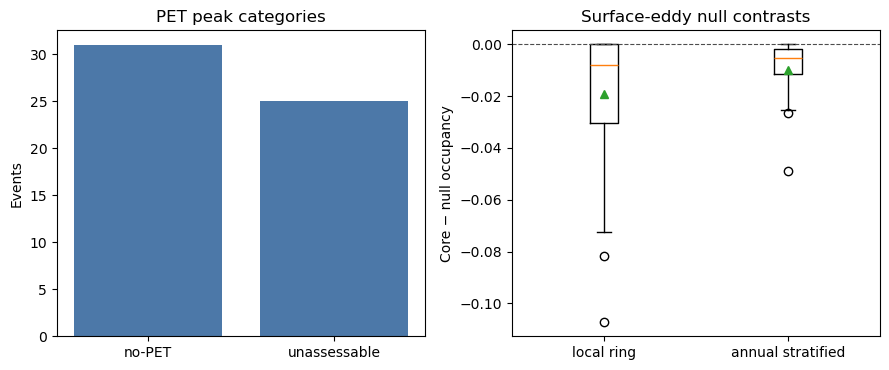

In [22]:
if surface_result is not None:
    _try(track.plot_ofes_surface_eddy_diagnostics, surface_result, show_fig=True, save_fig=False)


PET-eligible, unassessable, and negative outcomes remain distinct in the returned tables. The null comparisons use the event rows supplied to the reducer.

## 14. Isopycnal velocity and winter MLD diagnostics

These two diagnostics link the primary event population to the along-front vertical velocity and to the winter mixed-layer depth scale. They consume event association and completed upstream tables; the notebook does not reproduce their field calculations. Each result reports its own field-availability denominator and does not inherit 161 as an automatic success count.

In [ ]:
walong_run = track.run_ofes_event_isopycnal_velocity_audit(
    OFES_OUTPUT_ROOT / 'primary_event_population' / 'population_peak_diagnostics.parquet',
    population_scope='primary_300_1000',
    trajectory_classification_path=OFES_OUTPUT_ROOT / 'primary_trajectory_3d_population' / 'population_classification.parquet',
    output_dir=OFES_OUTPUT_ROOT / 'primary_w_along',
)
winter_mld_run = track.run_ofes_event_winter_mld_audit(
    OFES_OUTPUT_ROOT / 'primary_event_population' / 'population_peak_diagnostics.parquet',
    population_scope='primary_300_1000',
    trajectory_horizon_summary_path=OFES_OUTPUT_ROOT / 'primary_trajectory_ventilation' / 'event_horizon_summary.parquet',
    trajectory_classification_path=OFES_OUTPUT_ROOT / 'primary_trajectory_3d_population' / 'population_classification.parquet',
    output_dir=OFES_OUTPUT_ROOT / 'primary_winter_mld',
)


In [23]:
walong_result = _try(track.load_ofes_event_isopycnal_velocity_audit, population_scope='primary_300_1000', output_dir=OFES_OUTPUT_ROOT / 'primary_w_along')
winter_mld_result = _try(track.load_ofes_event_winter_mld_audit, population_scope='primary_300_1000', output_dir=OFES_OUTPUT_ROOT / 'primary_winter_mld')
if walong_result is not None:
    _preview(walong_result.get('daily_metrics'), ['event_id', 'aggregation', 'region', 'core_w_along_mean', 'ring_w_along_mean'])
if winter_mld_result is not None:
    _preview(winter_mld_result.get('event_summary'), ['event_id', 'core_depth_m', 'winter_max_mld_m', 'resolved_downward_pathway_supported'])


,event_id,region,core_w_along_mean,ring_w_along_mean
0,OFES_DO50_E000002,core,-3.335009,NaN
1,OFES_DO50_E000002,ring,NaN,0.194047
2,OFES_DO50_E000002,core,-3.427129,NaN
3,OFES_DO50_E000002,ring,NaN,-0.784893
4,OFES_DO50_E000002,core,-4.815257,NaN
5,OFES_DO50_E000002,ring,NaN,-1.092505
6,OFES_DO50_E000002,core,-9.061970,NaN
7,OFES_DO50_E000002,ring,NaN,-1.064733


,event_id,core_depth_m,winter_max_mld_m,resolved_downward_pathway_supported
0,OFES_DO50_E000002,539.385803,376.838759,False
1,OFES_DO50_E000222,603.090820,451.648892,True
2,OFES_DO50_E000276,664.494080,227.646901,True
3,OFES_DO50_E000034,348.239563,236.295786,False
4,OFES_DO50_E000073,603.090820,313.815190,True
5,OFES_DO50_E000267,603.090820,398.265298,True
6,OFES_DO50_E000260,492.500000,193.599365,True
7,OFES_DO50_E000233,539.385803,191.800870,False


In [24]:
if walong_result is not None and 'date' in walong_result.get('daily_metrics', pd.DataFrame()).columns:
    _try(track.plot_ofes_event_isopycnal_velocity_audit, walong_result, show_fig=True, save_fig=False)
if winter_mld_result is not None:
    _try(track.plot_ofes_event_winter_mld_audit, winter_mld_result, show_fig=True, save_fig=False)


The velocity and MLD outputs are linked mechanism diagnostics. They do not create a new event identity or alter the upstream water-mass measurements.

## 15. Formation-to-organization transition and retention

The transition reducer compares early, peak, and late phases for the 300–1000 m primary population, then summarizes lag and post-peak response at event level. The reader and plot expose those formal tables directly; lifecycle, retention, and each optional upstream table retain their own eligible denominators.

In [ ]:
fixed_water_retention_run = track.run_ofes_event_daily_water_mass_audit(
    OFES_OUTPUT_ROOT / 'primary_event_population' / 'population_peak_diagnostics.parquet',
    population_scope='primary_300_1000',
    geometry_mode='fixed_site',
    daily_water_mass_path=OFES_OUTPUT_ROOT / 'primary_daily_water_mass' / 'fixed_site' / 'daily_water_mass.parquet',
    lifecycle_path=OFES_OUTPUT_ROOT / 'primary_event_lifecycle' / 'lifecycle_event_summary.parquet',
    output_dir=OFES_OUTPUT_ROOT / 'primary_mechanism_water_mass' / 'fixed_site',
)
moving_water_retention_run = track.run_ofes_event_daily_water_mass_audit(
    OFES_OUTPUT_ROOT / 'primary_event_population' / 'population_peak_diagnostics.parquet',
    population_scope='primary_300_1000',
    geometry_mode='moving_core',
    daily_water_mass_path=OFES_OUTPUT_ROOT / 'primary_daily_water_mass' / 'moving_core' / 'daily_water_mass.parquet',
    lifecycle_path=OFES_OUTPUT_ROOT / 'primary_event_lifecycle' / 'lifecycle_event_summary.parquet',
    output_dir=OFES_OUTPUT_ROOT / 'primary_mechanism_water_mass' / 'moving_core',
)

transition_run = track.run_ofes_event_mechanism_transition_audit(
    OFES_OUTPUT_ROOT / 'primary_event_population' / 'population_peak_diagnostics.parquet',
    population_scope='primary_300_1000',
    lifecycle_path=OFES_OUTPUT_ROOT / 'primary_event_lifecycle' / 'lifecycle_daily_diagnostics.parquet',
    lifecycle_summary_path=OFES_OUTPUT_ROOT / 'primary_event_lifecycle' / 'lifecycle_event_summary.parquet',
    trajectory_classification_path=OFES_OUTPUT_ROOT / 'primary_trajectory_3d_population' / 'population_classification.parquet',
    stage_bridge_path=OFES_OUTPUT_ROOT / 'primary_mccoy_virtual_argo_stage_bridge' / 'stage_diagnostics.parquet',
    fixed_water_mass_path=OFES_OUTPUT_ROOT / 'primary_mechanism_water_mass' / 'fixed_site' / 'event_summary.parquet',
    moving_water_mass_path=OFES_OUTPUT_ROOT / 'primary_mechanism_water_mass' / 'moving_core' / 'event_summary.parquet',
    mccoy_path=OFES_OUTPUT_ROOT / 'primary_mccoy_virtual_argo' / 'event_summary.parquet',
    walong_path=OFES_OUTPUT_ROOT / 'primary_w_along',
    ventilation_path=OFES_OUTPUT_ROOT / 'primary_trajectory_ventilation',
    tracer_daily_path=OFES_OUTPUT_ROOT / 'primary_trajectory_tracers' / 'daily_tracer_summary.parquet',
    tracer_event_path=OFES_OUTPUT_ROOT / 'primary_trajectory_tracers' / 'event_tracer_summary.parquet',
    output_dir=OFES_OUTPUT_ROOT / 'primary_mechanism_synthesis',
)


In [25]:
fixed_water_retention_result = _try(
    track.load_ofes_event_daily_water_mass_audit,
    OFES_OUTPUT_ROOT / 'primary_mechanism_water_mass' / 'fixed_site',
)
moving_water_retention_result = _try(
    track.load_ofes_event_daily_water_mass_audit,
    OFES_OUTPUT_ROOT / 'primary_mechanism_water_mass' / 'moving_core',
)
transition_result = _try(track.load_ofes_event_mechanism_transition_audit, population_scope='primary_300_1000', output_dir=OFES_OUTPUT_ROOT / 'primary_mechanism_synthesis')
if transition_result is not None:
    _preview(transition_result.get('phase_transition_table'), ['event_id', 'early_class', 'peak_class', 'late_class', 'transition', 'resolved_downward'])
    _preview(transition_result.get('retention_comparison'), ['event_id', 'persistent_carrier', 'post_peak_decay_slope', 'do_fingerprint_day_fraction'])
    _preview(transition_result.get('event_lag_diagnostics'), ['event_id', 'formation_to_organization_lag_days', 'n_days'])


,event_id,early_class,peak_class,late_class,transition,resolved_downward
0,OFES_DO50_E000002,strain,rotation,rotation,strain->rotation,False
1,OFES_DO50_E000222,strain,rotation,strain,strain->strain,True
2,OFES_DO50_E000276,rotation,rotation,rotation,rotation->rotation,True
3,OFES_DO50_E000034,strain,strain,strain,strain->strain,False
4,OFES_DO50_E000073,strain,rotation,rotation,strain->rotation,True
5,OFES_DO50_E000267,rotation,rotation,strain,rotation->strain,True
6,OFES_DO50_E000260,strain,rotation,strain,strain->strain,True
7,OFES_DO50_E000233,rotation,rotation,strain,rotation->strain,False


,event_id,persistent_carrier,post_peak_decay_slope,do_fingerprint_day_fraction
0,OFES_DO50_E000002,True,-0.033753,0.478261
1,OFES_DO50_E000222,False,-0.023797,0.833333
2,OFES_DO50_E000276,True,-0.009821,1.000000
3,OFES_DO50_E000034,False,-0.023256,0.800000
4,OFES_DO50_E000073,True,-0.006273,1.000000
5,OFES_DO50_E000267,True,-0.003301,1.000000
6,OFES_DO50_E000260,False,-0.046963,0.600000
7,OFES_DO50_E000233,False,-0.030830,0.583333


,event_id,formation_to_organization_lag_days,n_days
0,OFES_DO50_E000002,5.0,36
1,OFES_DO50_E000222,1.0,32
2,OFES_DO50_E000276,-5.0,55
3,OFES_DO50_E000034,2.0,16
4,OFES_DO50_E000073,5.0,28
5,OFES_DO50_E000267,5.0,32
6,OFES_DO50_E000260,3.0,14
7,OFES_DO50_E000233,-5.0,21


In [26]:
if transition_result is not None:
    _try(track.plot_ofes_event_mechanism_transition_audit, transition_result, show_fig=True, save_fig=False)


The transition and retention outputs describe linked event histories. They are mechanism diagnostics, not a new SCV identity criterion.

## 16. Linked population summary

This summary places the primary event, trajectory, McCoy, ventilation, and mechanism tables on a common event index. It is a compact audit view before assembling the manuscript figures; optional deep-only onset/patch and representative audits remain outside this primary mechanism chain.

In [27]:
mechanism_summary = track.summarize_ofes_mechanism_synthesis(
    transition_result=transition_result,
    walong_result=walong_result,
    winter_mld_result=winter_mld_result,
    stage_result=stage_bridge_result,
)
display(pd.DataFrame([mechanism_summary]))


,event_count,retention_usable_events,linked
0,147,147,"{'walong': {'rows': 2058, 'summary': {'analyti..."


Counts in this view are derived from the loaded tables and are not used as permanent execution gates.

## 17. Manuscript Figures 1–6

The final figure functions are thin consumers. Their inputs are explicit formal tables; the cells below only adapt column names where a shared table uses a shorter field name. Running a figure cell overwrites its named PNG in the manuscript preview directory.

In [28]:
from IPython.display import Image
from plot_ofes_manuscript_figures import render_manuscript_figures_from_results
from plot_ofes_surface_eddy_paper_figures import render_paper_figures

figure_inputs_available = all(
    value is not None
    for value in (
        quality_result, mccoy_result, ventilation_result,
        trajectory_population_result, transition_result,
        walong_result, lifecycle_result,
        fixed_water_retention_result, moving_water_retention_result,
        stage_bridge_result,
    )
)
if figure_inputs_available:
    threshold_table = _read_table(
        GLOBAL_OUTPUT_ROOT / 'mccoy_scv_delta_do_thresholds' / 'mccoy_scv_delta_do_thresholds_2002_2023_depth300m.parquet'
    )
    sweep_table = _read_table(
        GLOBAL_OUTPUT_ROOT / 'scv_do_threshold_sweep' / 'scv_do_threshold_sweep_2002_2023_depth300m.parquet'
    )
    quality_table = quality_result['event_diagnostic_summary'].rename(columns={
        'water_mass_do_contrast': 'peak_water_mass_do_contrast',
        'heave_do_contribution': 'peak_heave_do_contribution',
        'same_sigma_theta_contrast': 'peak_same_sigma_theta_contrast',
        'same_sigma_salinity_contrast': 'peak_same_sigma_salinity_contrast',
    })
    mccoy_event_table = mccoy_result['event_summary']
    mccoy_summary = mccoy_result['analysis_summary']
    ventilation_group_table = ventilation_result['group_comparison']
    trajectory_classification_table = trajectory_population_result['population_classification']
    transition_phase_table = transition_result['phase_transition_table']
    walong_table = walong_result['audit']
    ventilation_daily_table = ventilation_result['daily_diagnostics']
    lifecycle_table = lifecycle_result['event_summary']
    retention_table = transition_result['retention_comparison']
    transition_summary = transition_result['summary']
    fixed_water_summary = fixed_water_retention_result['summary']
    moving_water_summary = moving_water_retention_result['summary']
    stage_table = stage_bridge_result['stage_diagnostics']
else:
    manuscript_figure_paths = []
    print('Manuscript figure inputs are unavailable; retaining existing frozen figure outputs.')


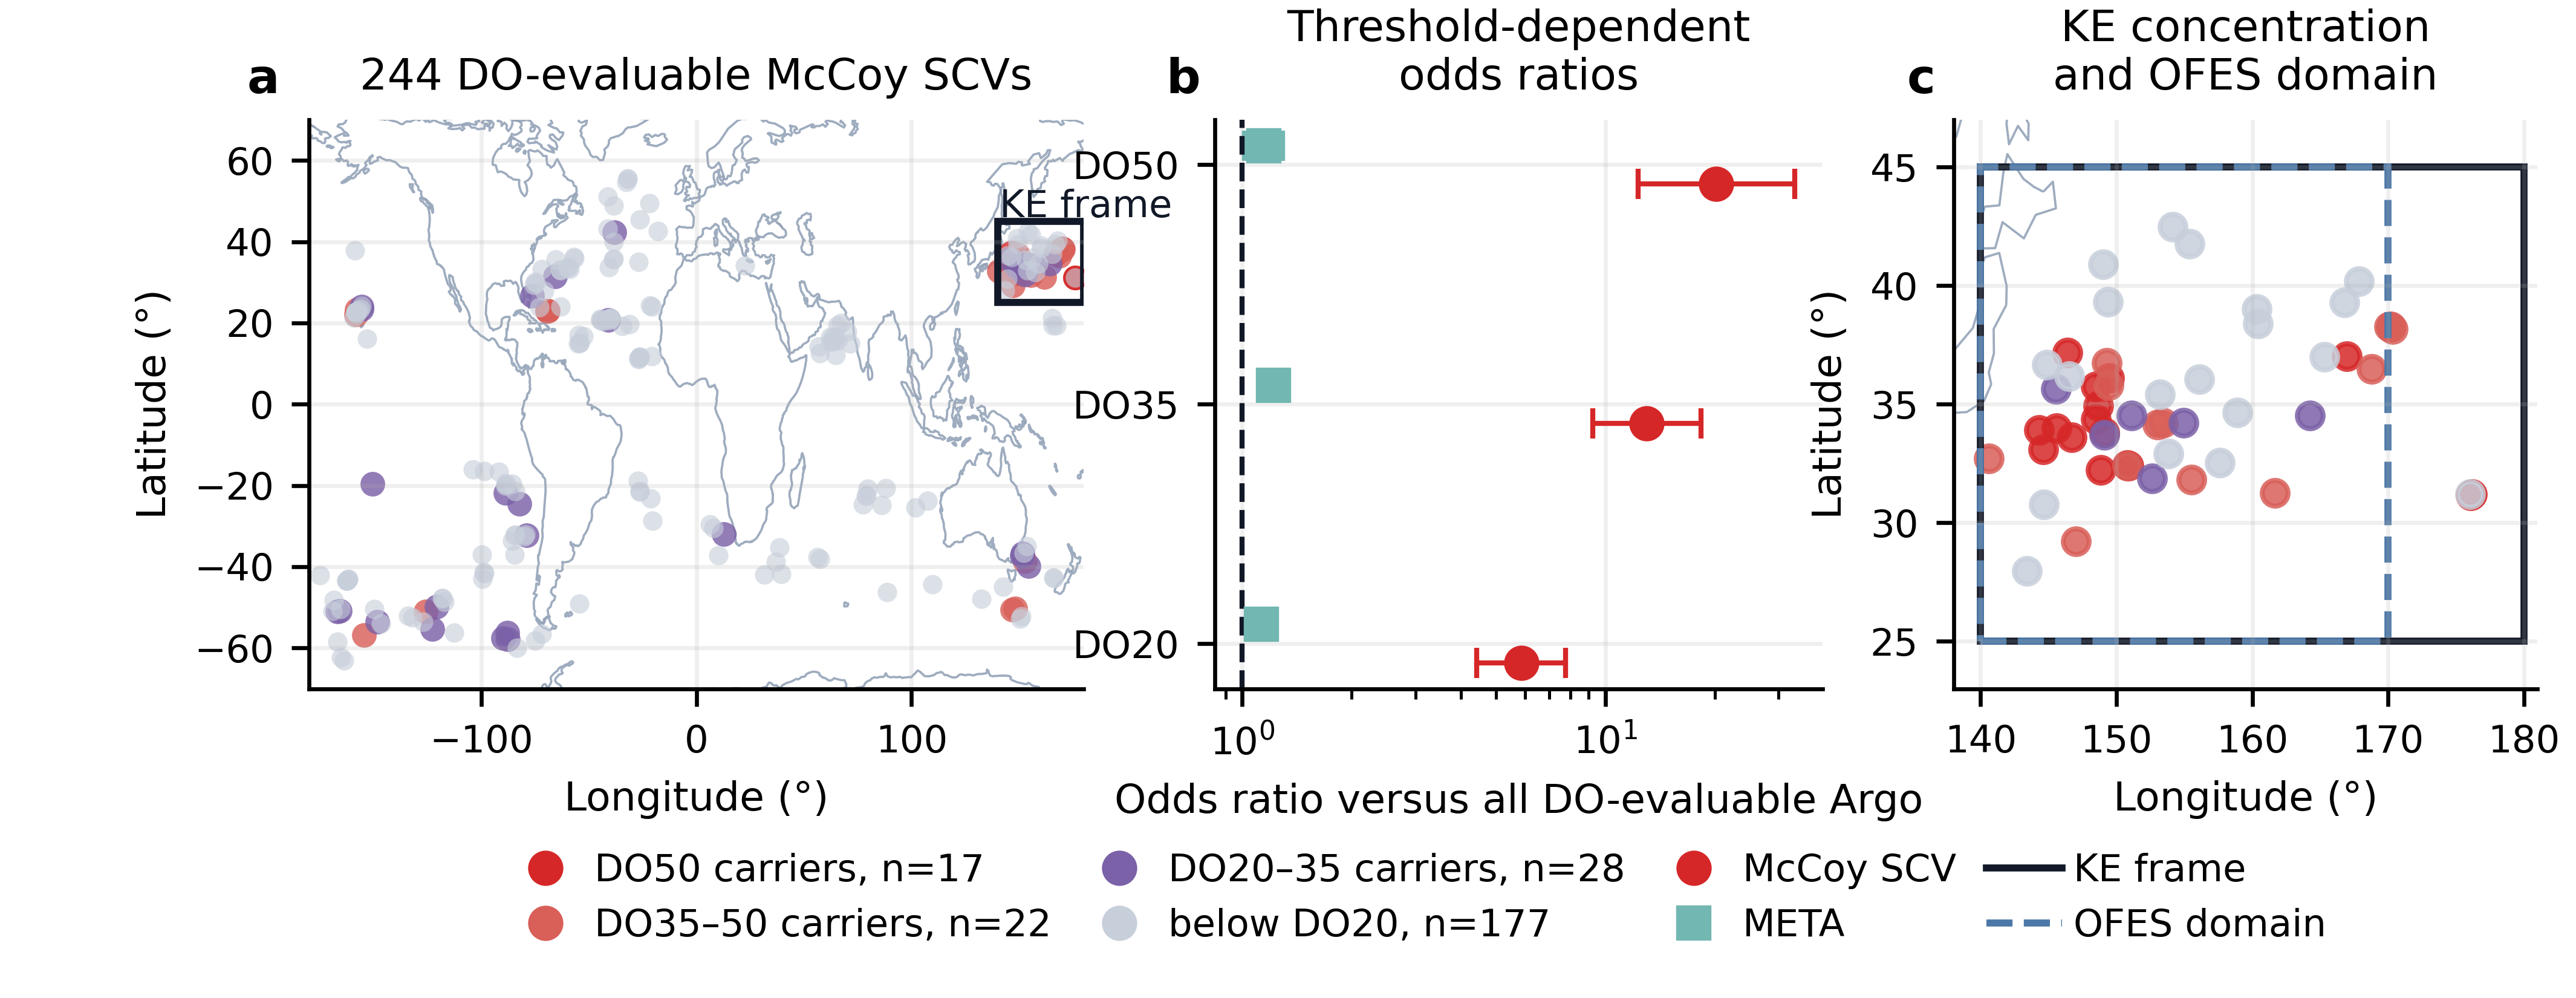

In [29]:
if figure_inputs_available:
    manuscript_figure_paths = render_manuscript_figures_from_results(
        threshold_table,
        sweep_table,
        quality_table,
        mccoy_event_table,
        mccoy_summary,
        ventilation_group_table,
        trajectory_classification_table,
        transition_phase_table,
        walong_table,
        ventilation_daily_table,
        lifecycle_table,
        stage_table,
        retention_table,
        transition_summary,
        fixed_water_summary,
        moving_water_summary,
        output_dir=FIGURE_ROOT,
        dpi=600,
    )
    display(Image(filename=str(manuscript_figure_paths[0])))
else:
    print('Manuscript figure rendering deferred because optional primary inputs are unavailable.')


Figure 1 derives the global threshold categories, odds ratios, and distinct KE/OFES frames from the supplied tables.

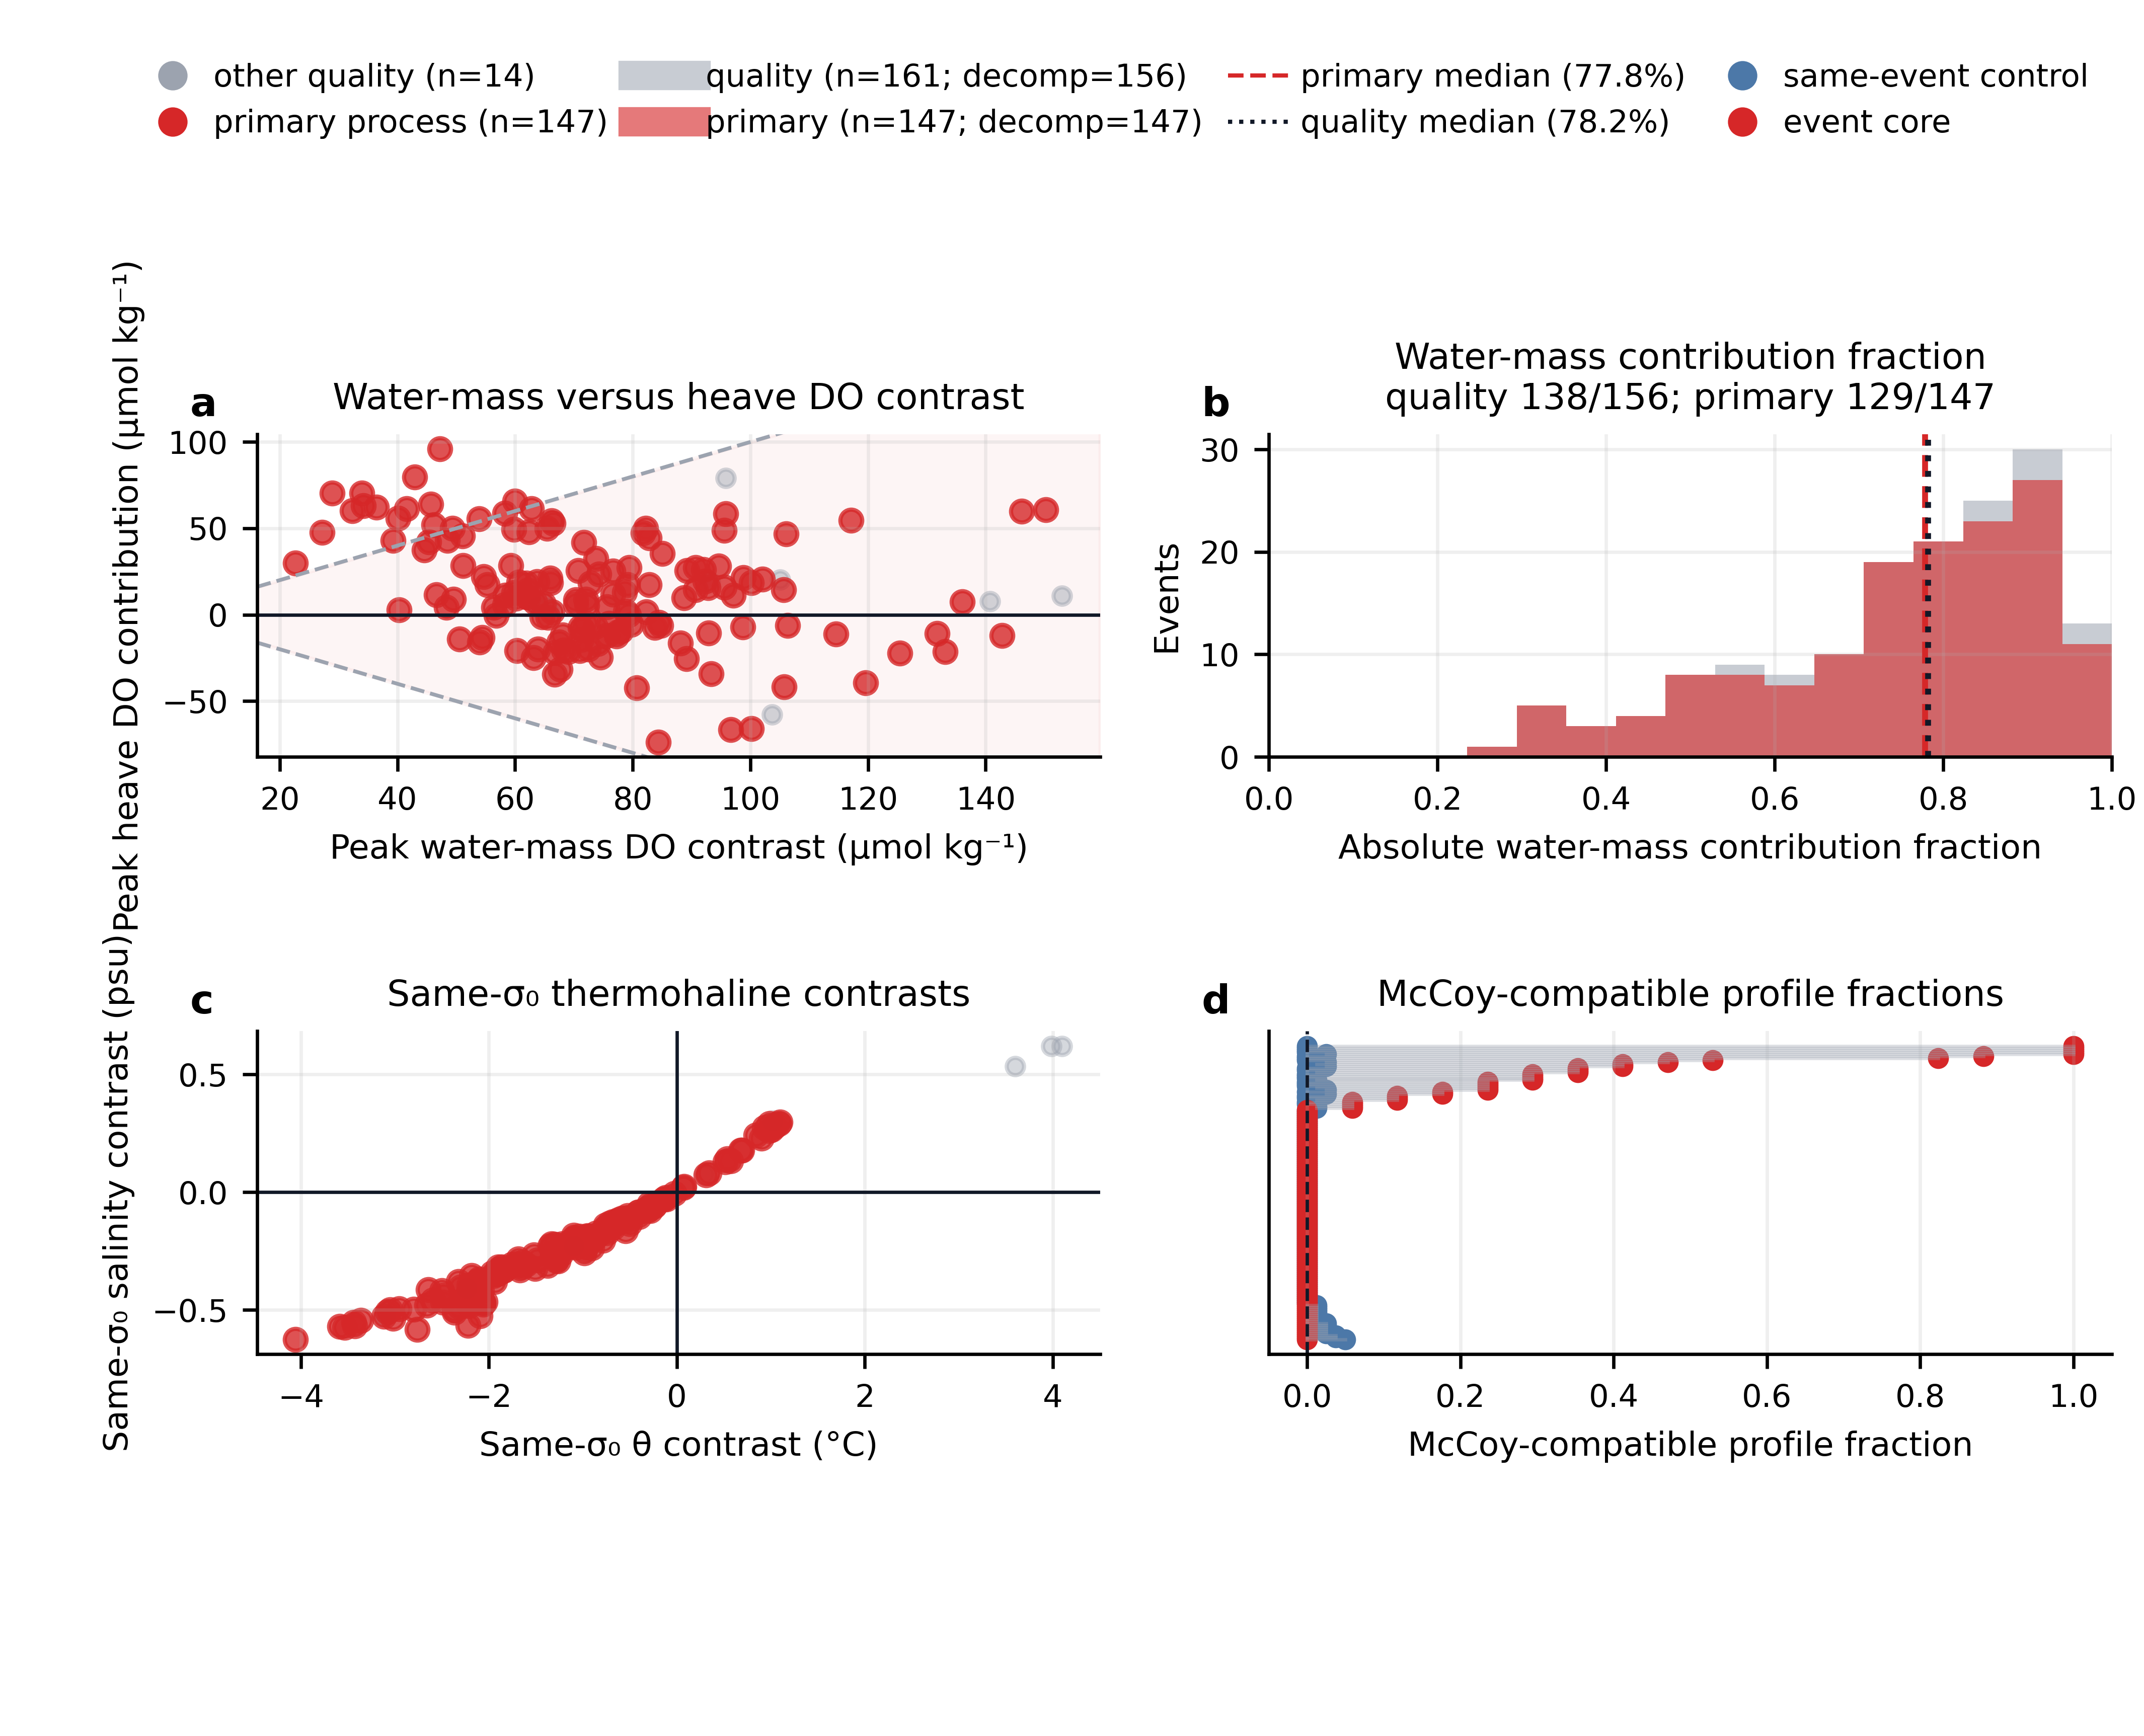

In [30]:
if manuscript_figure_paths:
    display(Image(filename=str(manuscript_figure_paths[1])))


Figure 2 shows the water-mass/heave decomposition and event/control McCoy fractions using a shared event index.

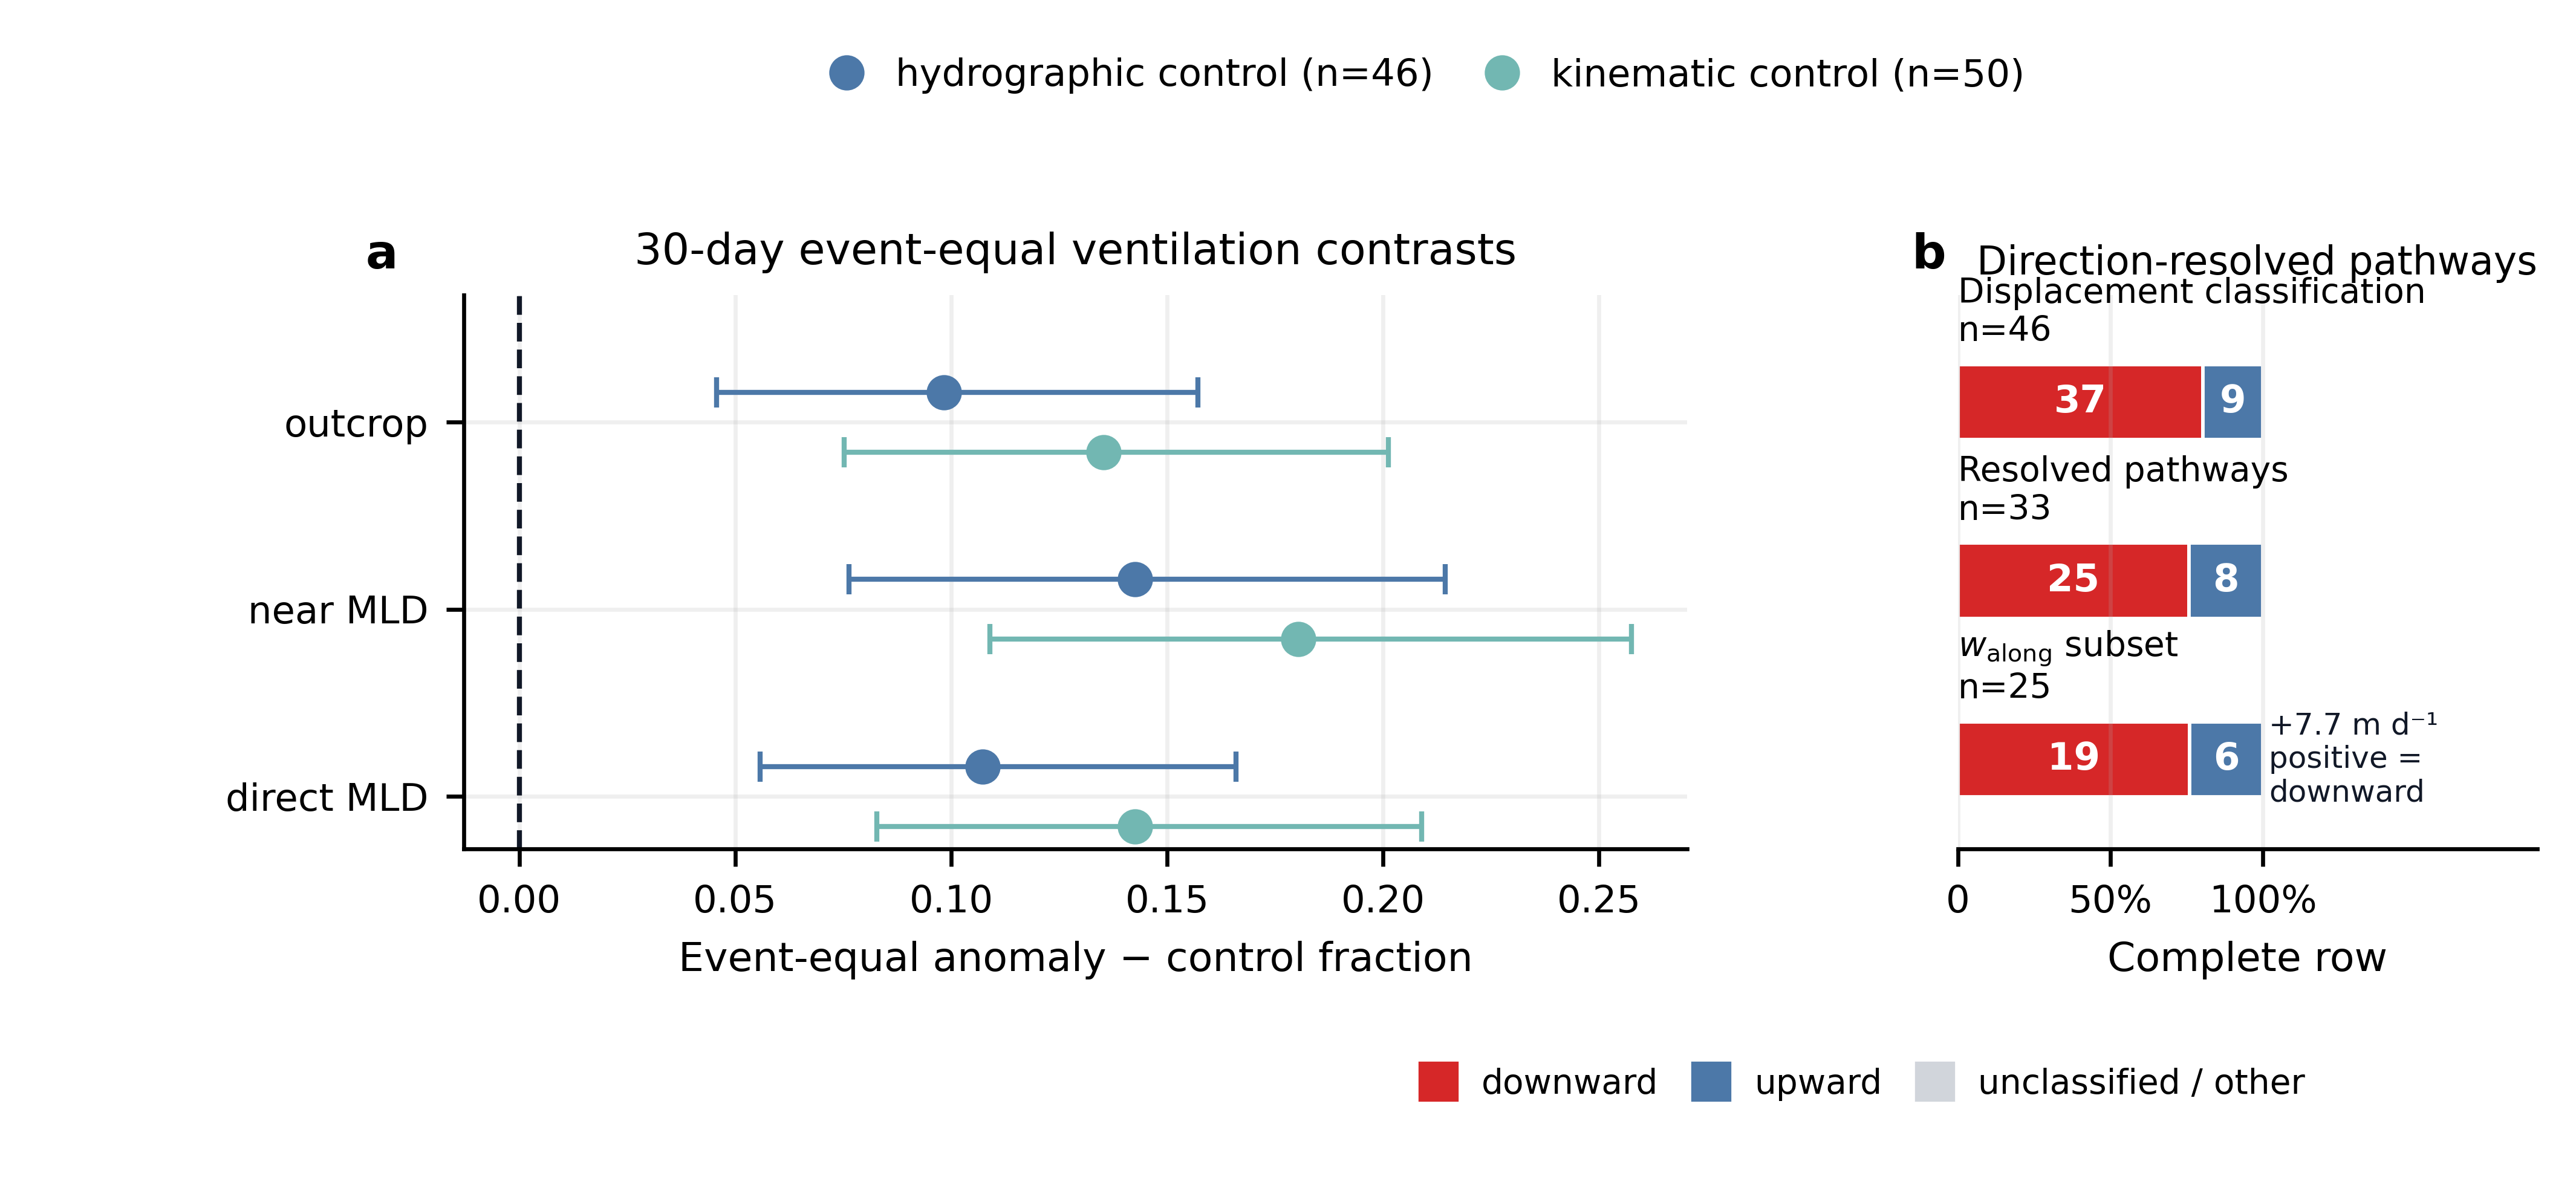

In [31]:
if manuscript_figure_paths:
    display(Image(filename=str(manuscript_figure_paths[2])))


Figure 3 keeps hydrographic, direction-resolved, and w-along denominators as separate rows.

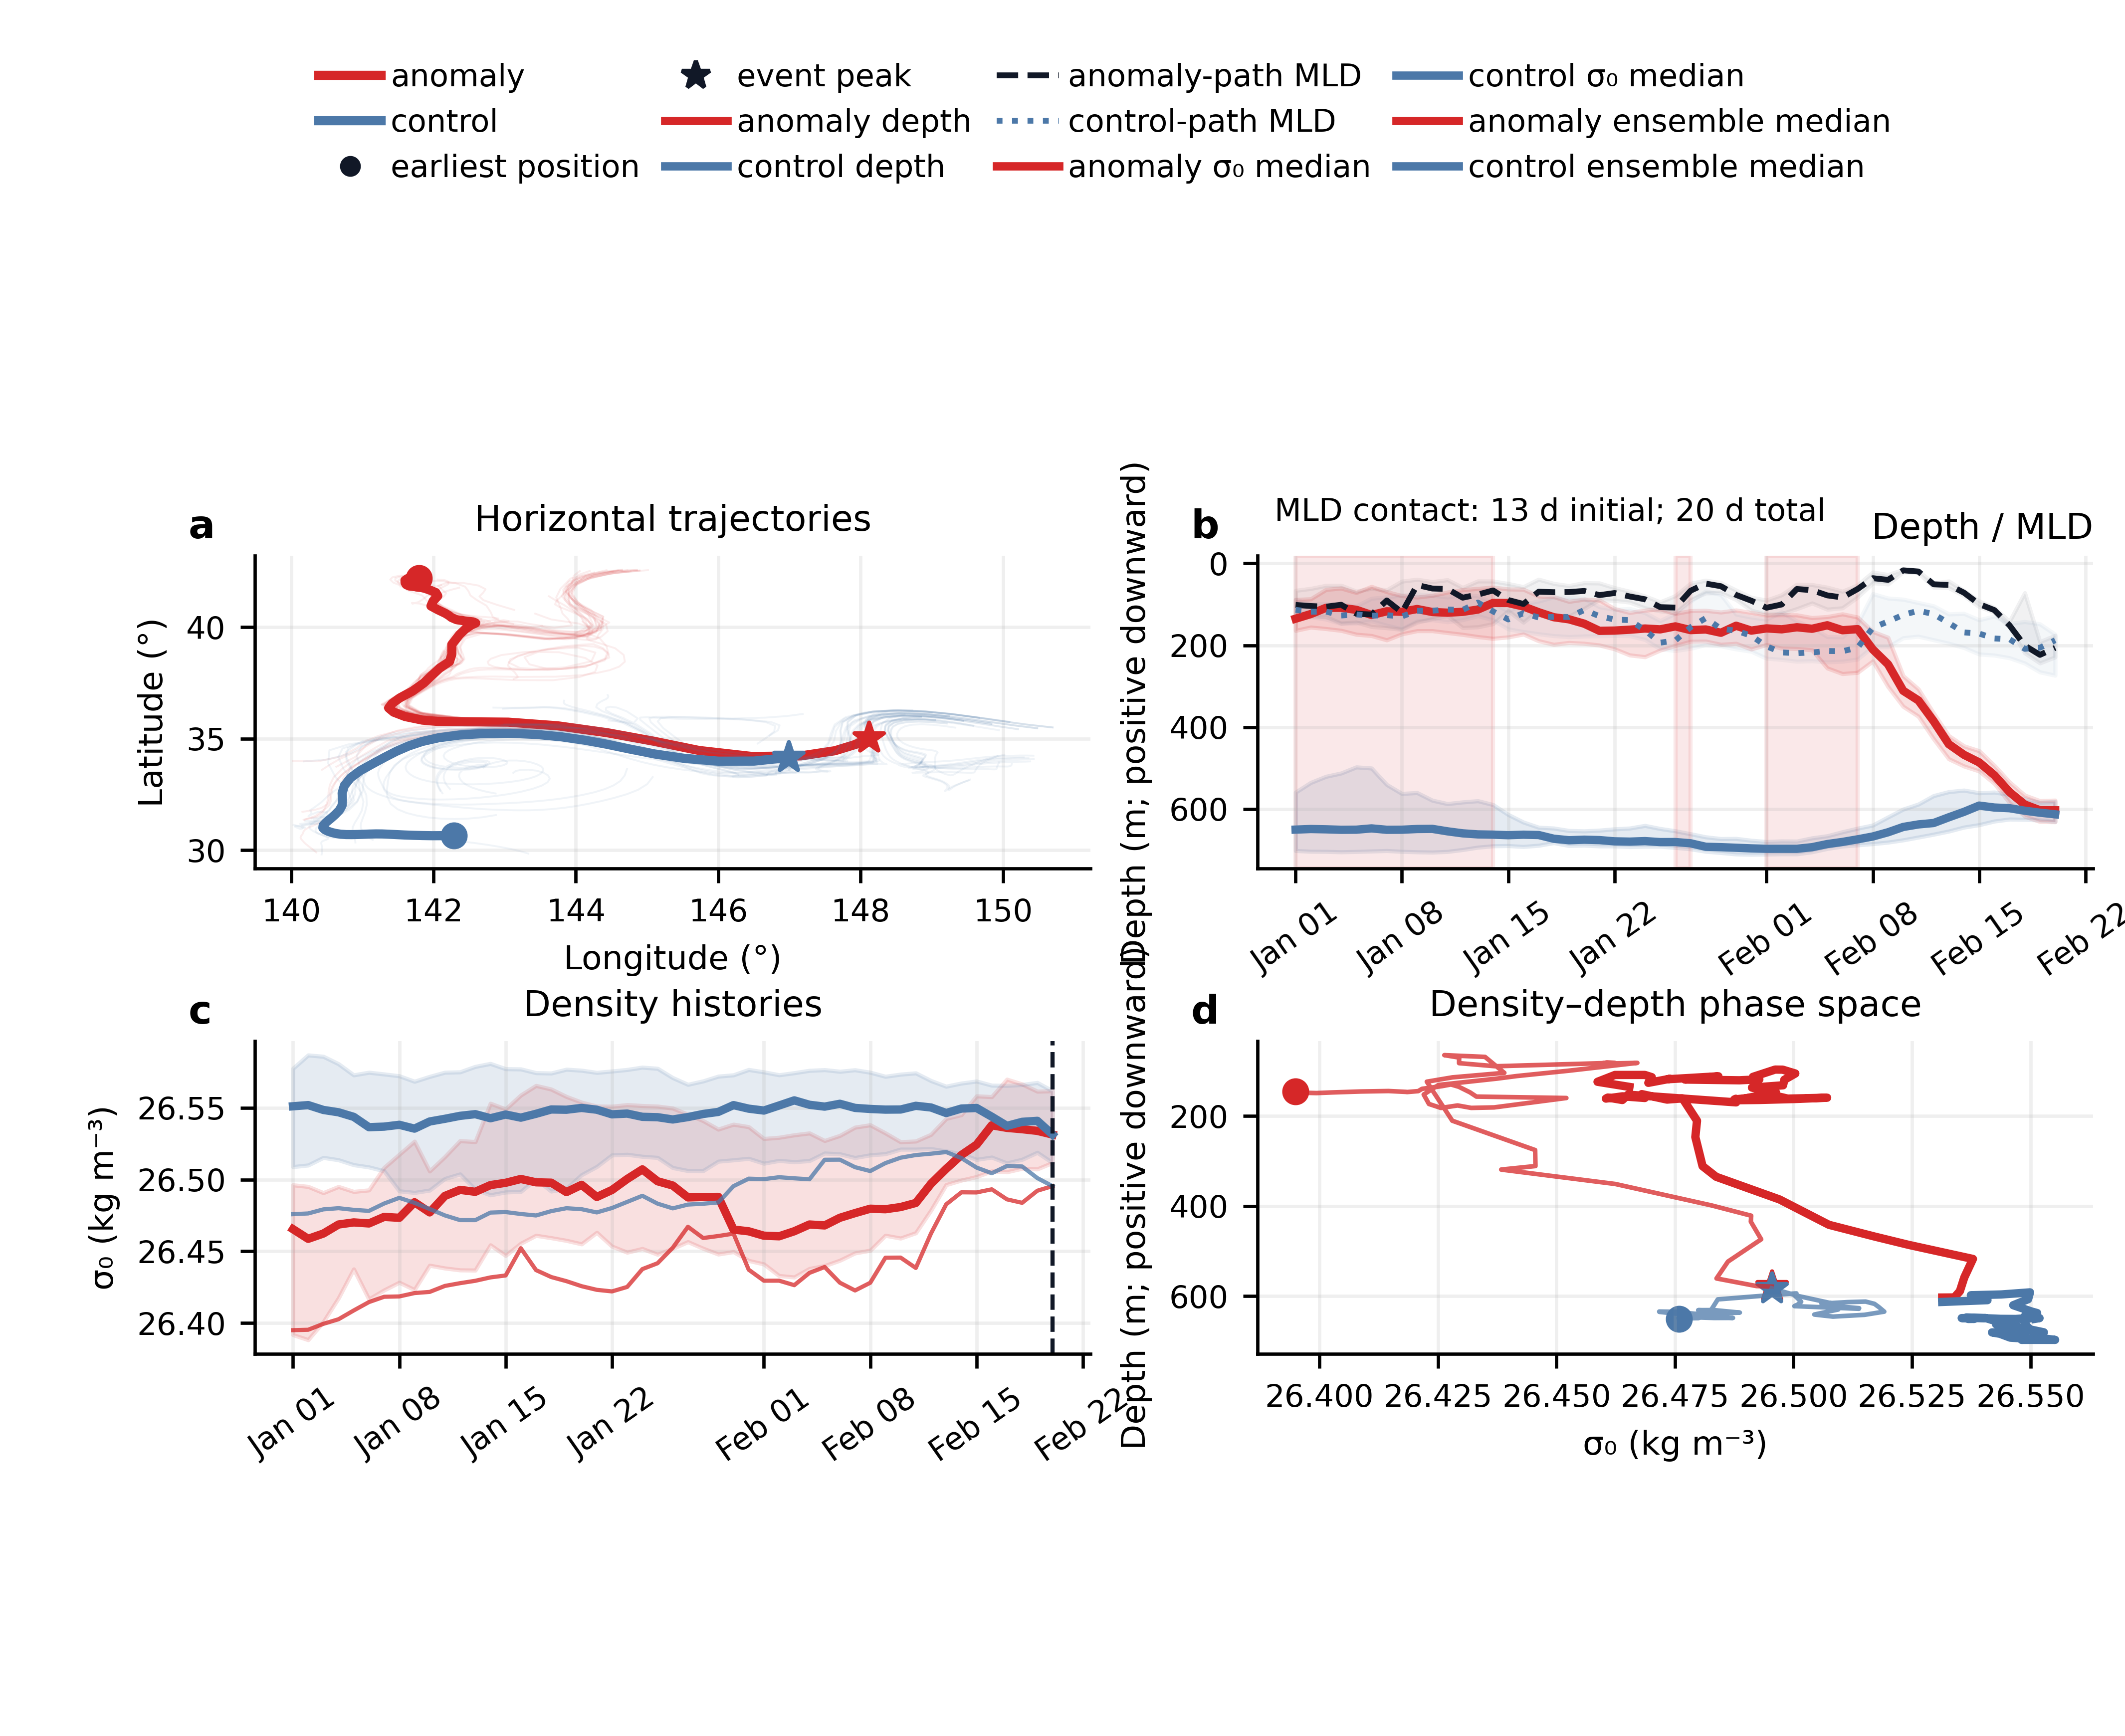

In [32]:
if manuscript_figure_paths:
    display(Image(filename=str(manuscript_figure_paths[3])))


Figure 4 displays one explicitly named ventilation case in chronological order.

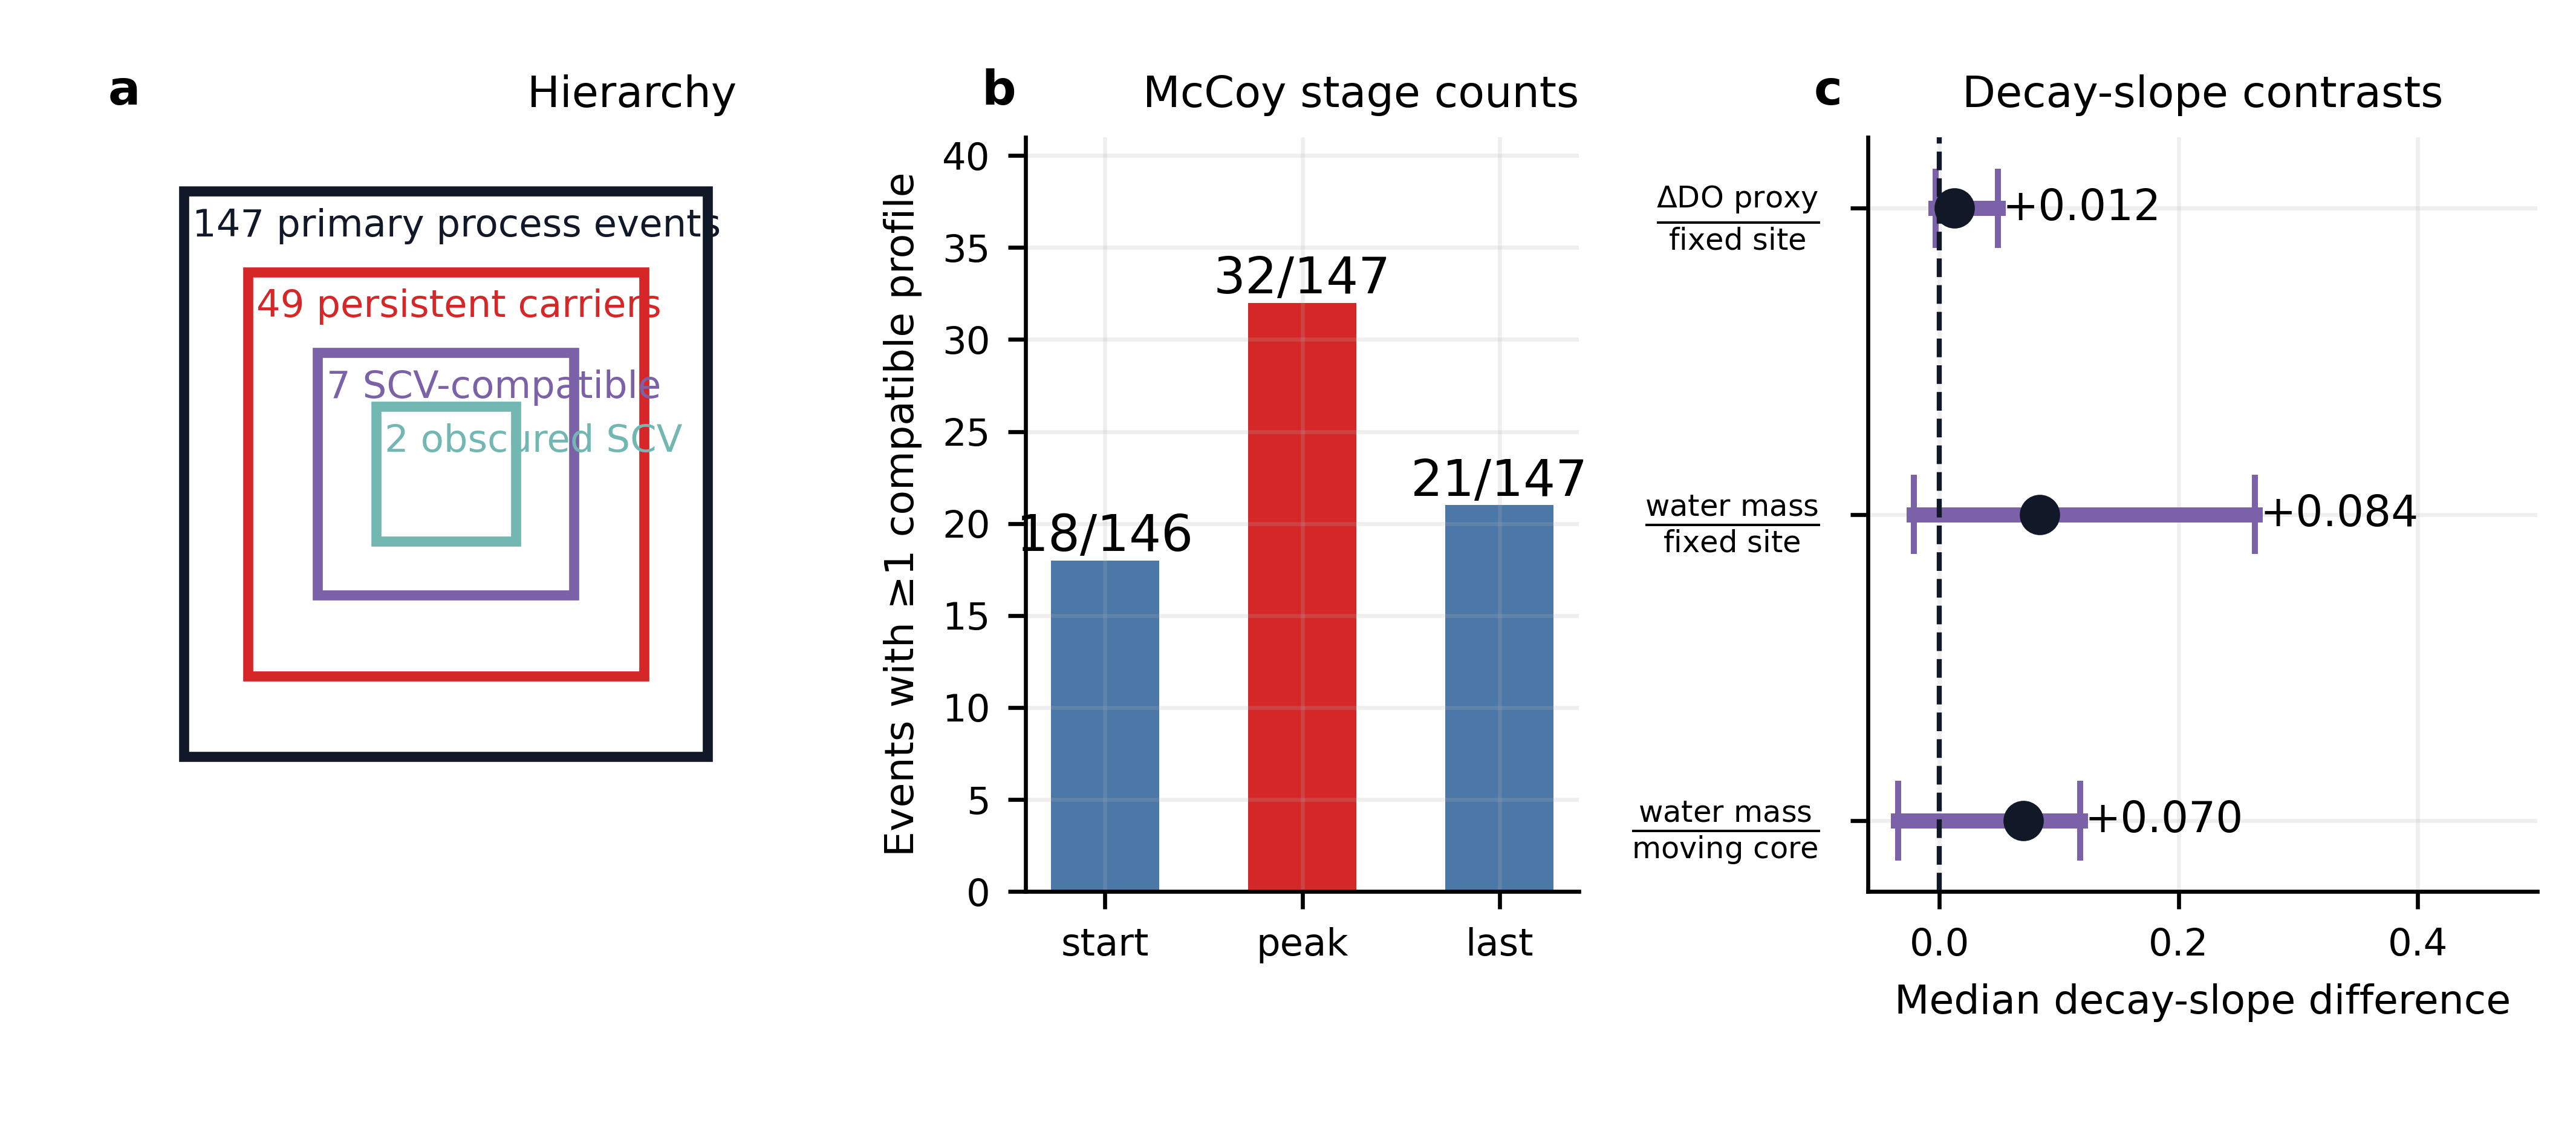

In [33]:
if manuscript_figure_paths:
    display(Image(filename=str(manuscript_figure_paths[4])))


Figure 5 derives its hierarchy, stage counts, and retention distribution from the three formal event tables.

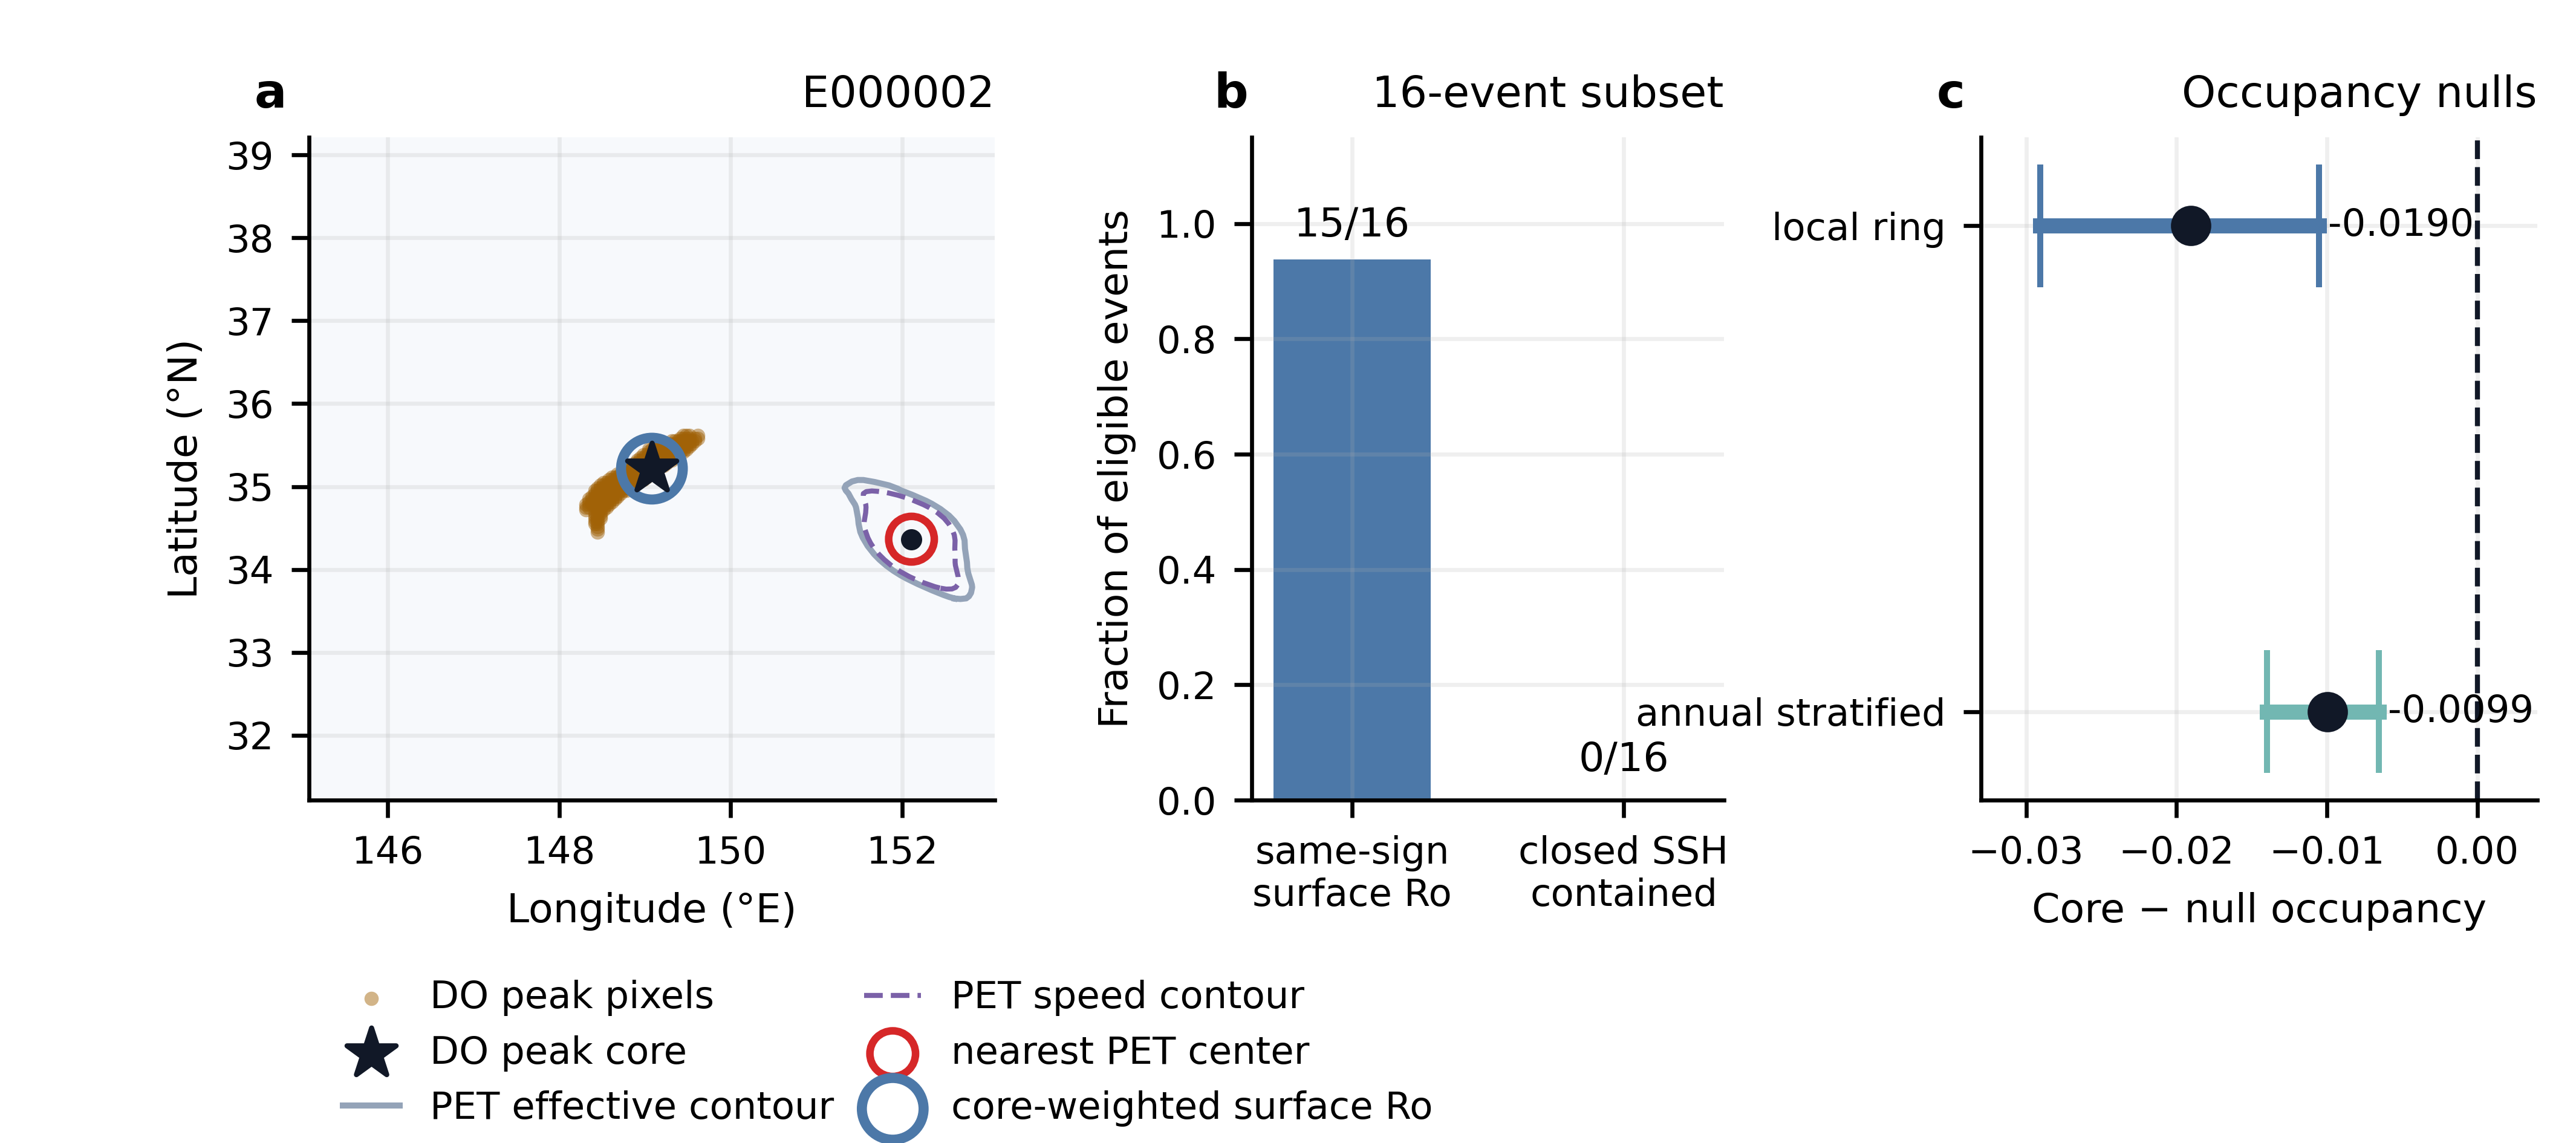

In [34]:
surface_figure_paths = _try(
    render_paper_figures,
    surface_root=SURFACE_ROOT,
    output_dir=FIGURE_ROOT,
    dpi=600,
    do_catalog_root=OFES_OUTPUT_ROOT / 'event_catalog',
    population_path=OFES_OUTPUT_ROOT / 'primary_event_population' / 'population_peak_diagnostics.parquet',
    case_event_id='OFES_DO50_E000002',
)
if surface_figure_paths:
    display(Image(filename=str(surface_figure_paths[0])))


Figure 6 uses the measured PET association and core-weighted surface Rossby marker. No synthetic spatial footprint is drawn in the notebook.

## 18. Supplementary depth-gate sensitivity


This supplementary reducer combines the completed 100 m and 300 m sensitivity summaries with the nested 500–1000 m deep-process subset. It reads existing parquet products only and does not rescan OFES or rerun PET.


,minimum_depth_m,estimate,water_mass_dominated_count,water_mass_dominated_denominator,median_heave_absolute_fraction
0,100.0,boundary_excluded,341.0,403.0,0.255183
1,100.0,main,406.0,482.0,0.279467
2,300.0,boundary_excluded,117.0,132.0,0.188439
3,300.0,main,138.0,156.0,0.218088
4,500.0,boundary_excluded,54.0,56.0,0.137815
5,500.0,main,54.0,56.0,0.137815


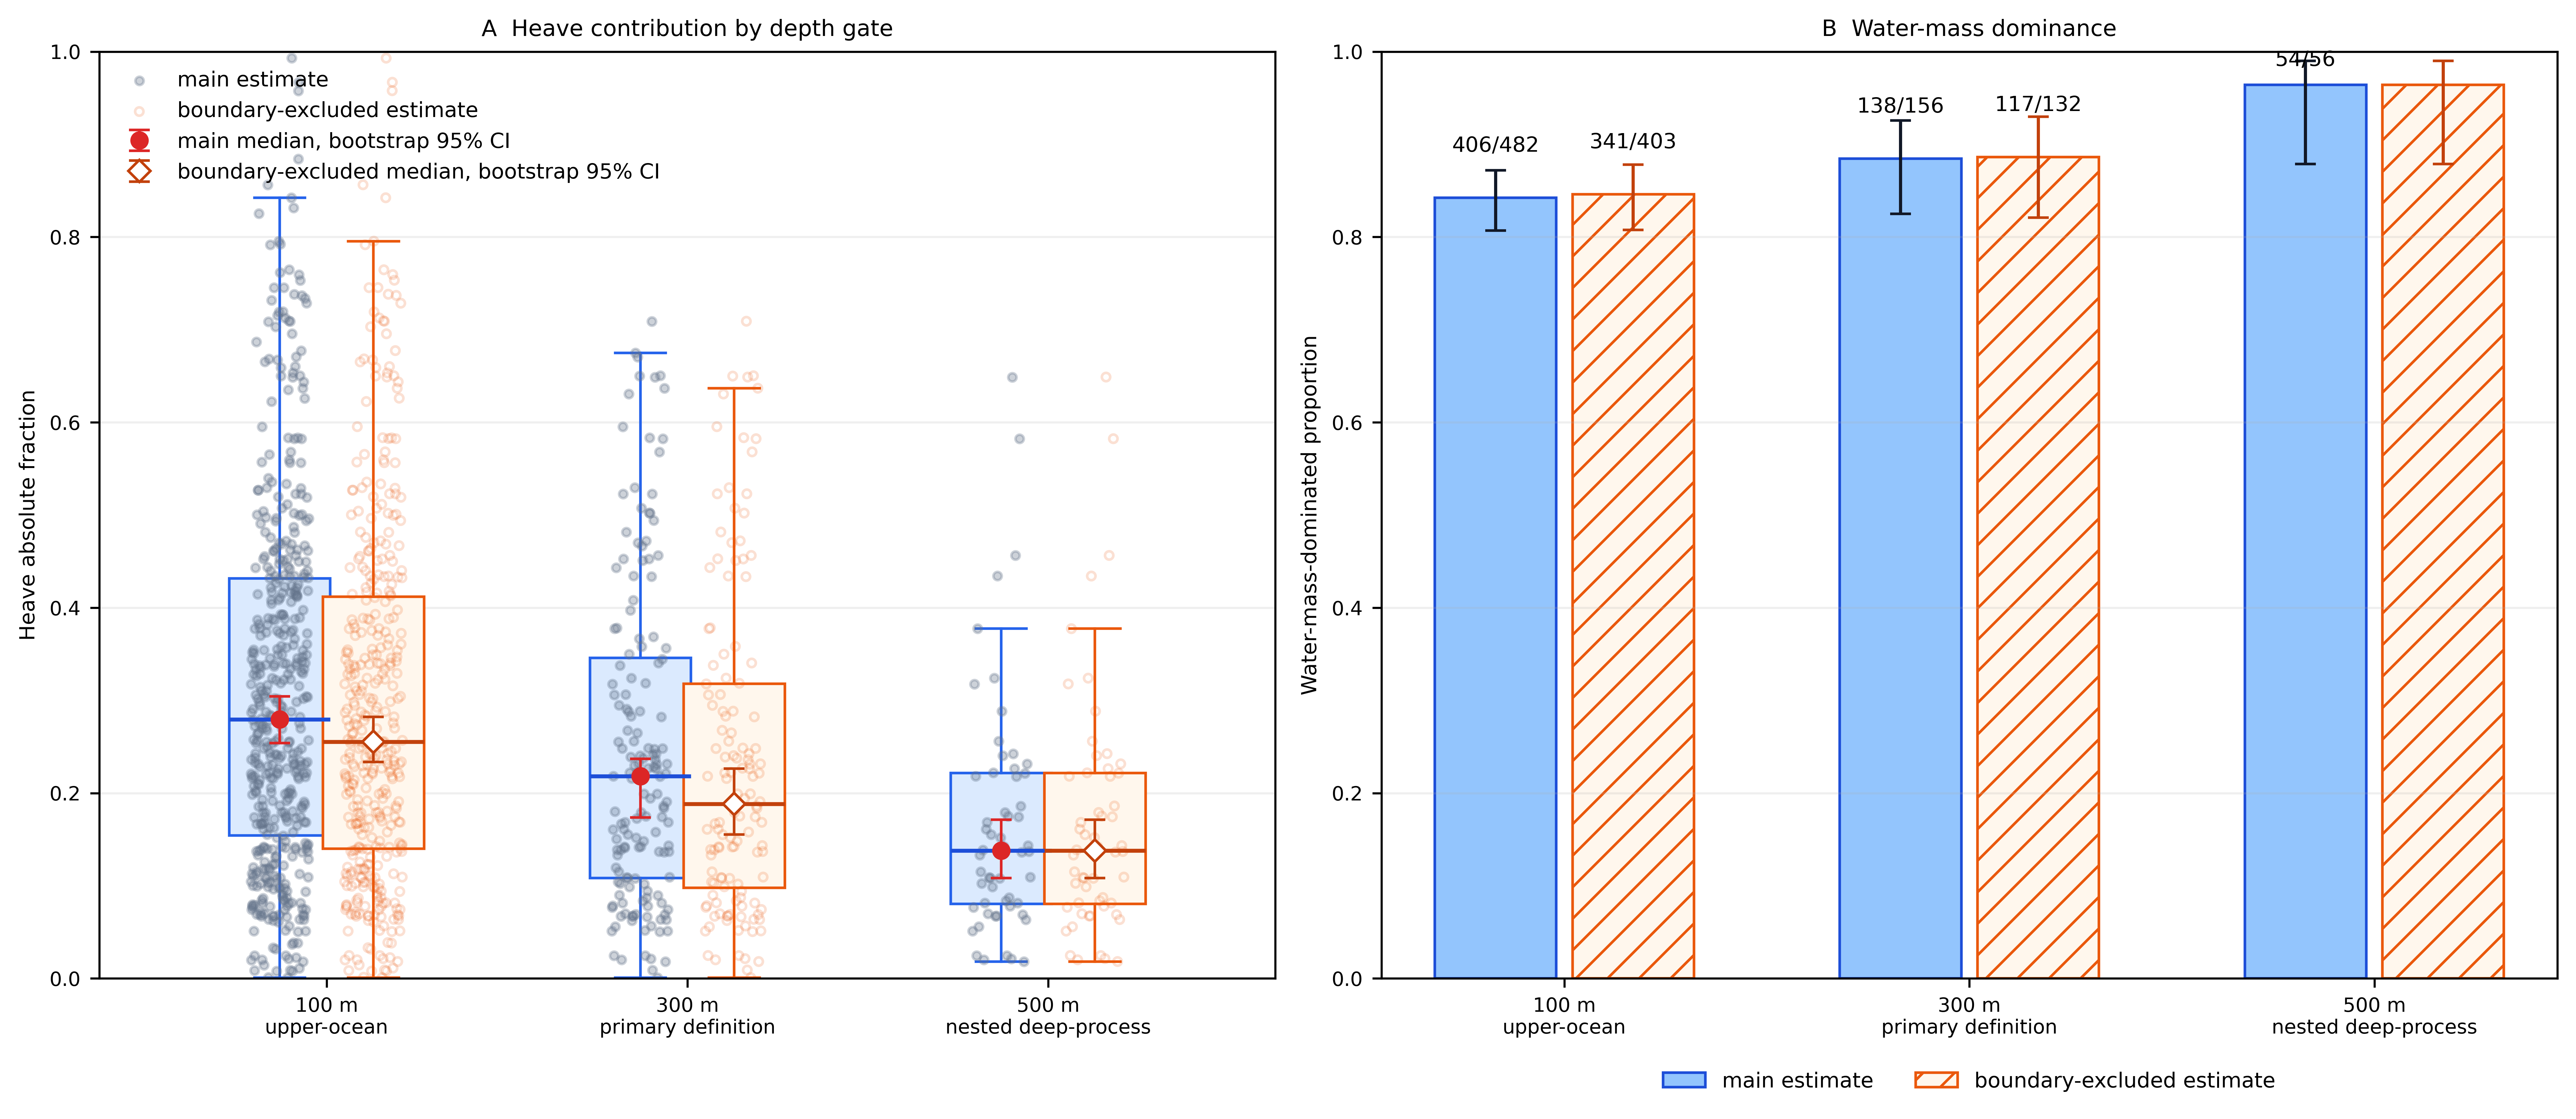

In [35]:
depth_sensitivity_supplement = _try(
    track.build_ofes_depth_gate_sensitivity_supplement,
    output_dir=OFES_OUTPUT_ROOT / 'depth_gate_sensitivity' / 'supplementary_100_300_500',
    dpi=600,
)
if depth_sensitivity_supplement is not None:
    _preview(
        depth_sensitivity_supplement.get('summary_table'),
        [
            'minimum_depth_m', 'estimate', 'water_mass_dominated_count',
            'water_mass_dominated_denominator', 'median_heave_absolute_fraction',
        ],
    )
    display(Image(filename=str(depth_sensitivity_supplement['figure_path'])))
